# Analyse individuelle — focus joueurs clés de la finale

Ce notebook prolonge directement l’analyse collective du `02`. Là où le notebook précédent montrait une **Argentine plus structurée dans la maîtrise du jeu** et une **France plus dangereuse par séquences explosives**, l’objectif ici est d’identifier **quels joueurs portent concrètement ces dynamiques**.

L’analyse avance en trois temps :
- comparer les profils offensifs des principaux acteurs,
- mesurer la qualité technique individuelle dans le dribble, la passe et la progression du ballon,
- replacer ces performances dans les structures collectives déjà observées à l’échelle du match.

Sauf mention contraire, les lectures offensives portent sur le **match et la prolongation**, en excluant la **séance de tirs au but**. Ce choix permet de garder le notebook aligné avec les conclusions du `02` et d’éviter de gonfler artificiellement les volumes de tirs, de buts ou de xG individuels.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ast
import os
import seaborn as sns
import unicodedata
from mplsoccer import Pitch
from matplotlib.lines import Line2D

# Chargement données
events = pd.read_csv("../data/raw/events_finale.csv")
# On garde le match et la prolongation, sans la séance de tirs au but.
events = events[events["period"] != 5].copy()

# Fonctions utilitaires
def parse_loc(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return None
    return x

def distance(loc1, loc2):
    if isinstance(loc1, list) and isinstance(loc2, list):
        return np.sqrt((loc2[0] - loc1[0]) ** 2 + (loc2[1] - loc1[1]) ** 2)
    return 0

def to_meters(d):
    return d * (105 / 120)

# Parsing coordonnées une seule fois
events["location"] = events["location"].apply(parse_loc)
events["pass_end_location"] = events["pass_end_location"].apply(parse_loc)
events["carry_end_location"] = events["carry_end_location"].apply(parse_loc)
events["x"] = events["location"].apply(lambda x: x[0] if isinstance(x, list) else None)
events["y"] = events["location"].apply(lambda x: x[1] if isinstance(x, list) else None)
events["end_x"] = events["pass_end_location"].apply(lambda x: x[0] if isinstance(x, list) else None)
events["end_y"] = events["pass_end_location"].apply(lambda x: x[1] if isinstance(x, list) else None)

os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("Prêt ✅")


Prêt ✅


In [2]:
# ============================================================
# Dictionnaire global des noms — appliqué UNE SEULE FOIS
# ============================================================
def simplify_name(name):
    if not isinstance(name, str):
        return name

    ascii_name = (
        unicodedata.normalize("NFKD", name)
        .encode("ascii", "ignore")
        .decode("ascii")
    )

    mapping = [
        ("Messi", "Messi"),
        ("Mbappe", "Mbappé"),
        ("Di Maria", "Di María"),
        ("Montiel", "Montiel"),
        ("Paredes", "Paredes"),
        ("Dybala", "Dybala"),
        ("Lautaro", "L. Martínez"),
        ("Mac Allister", "Mac Allister"),
        ("De Paul", "De Paul"),
        ("Julian Alvarez", "J. Álvarez"),
        ("Enzo Fernandez", "Enzo"),
        ("Kolo Muani", "Kolo Muani"),
        ("Rabiot", "Rabiot"),
        ("Tchouameni", "Tchouaméni"),
        ("Griezmann", "Griezmann"),
        ("Fofana", "Fofana"),
        ("Coman", "Coman"),
        ("Giroud", "Giroud"),
        ("Dembele", "Dembélé"),
        ("Camavinga", "Camavinga"),
        ("Otamendi", "Otamendi"),
        ("Romero", "Romero"),
        ("Tagliafico", "Tagliafico"),
        ("Upamecano", "Upamecano"),
        ("Molina", "Molina"),
        ("Acuna", "Acuna"),
        ("Emiliano Martinez", "E. Martinez"),
        ("Lloris", "Lloris"),
        ("Varane", "Varane"),
        ("Kounde", "Koundé"),
        ("Thuram", "Thuram"),
        ("Konate", "Konaté"),
    ]

    for key, short_name in mapping:
        if key in ascii_name:
            return short_name

    if "Theo" in ascii_name and "Hernandez" in ascii_name:
        return "T. Hernandez"

    return name


events["player"] = events["player"].apply(simplify_name)
for col in ["pass_recipient", "substitution_replacement"]:
    if col in events.columns:
        events[col] = events[col].apply(simplify_name)

name_display = {name: name for name in sorted(events["player"].dropna().unique())}

messi_full = "Messi"
mbappe_full = "Mbappé"

print("Noms simplifiés appliqués ✅")
print(f"Exemple : {events['player'].value_counts().head(5)}")


Noms simplifiés appliqués ✅
Exemple : player
Enzo        328
De Paul     242
Messi       241
Otamendi    215
Koundé      211
Name: count, dtype: int64


In [3]:

# ============================================================
# 1) BASE OFFENSIVE STATS
# ============================================================
shots = events[events["type"] == "Shot"].copy()

stats_tirs = shots.groupby(["player","team"]).agg(
    tirs        = ("type", "count"),
    tirs_cadres = ("shot_outcome", lambda x: x.isin(["Saved","Goal"]).sum()),
    buts        = ("shot_outcome", lambda x: (x == "Goal").sum()),
    xg_total    = ("shot_statsbomb_xg", "sum")
).reset_index()

stats_tirs["precision"] = (stats_tirs["tirs_cadres"] / stats_tirs["tirs"] * 100).round(1)
stats_tirs["xg_total"]  = stats_tirs["xg_total"].round(3)
stats_tirs = stats_tirs.sort_values("tirs", ascending=False)


## 1. Messi vs Mbappé : deux formes d’impact offensif

Cette ouverture résume parfaitement ce que montrait déjà le `02`. **Mbappé** termine avec le plus gros impact de finition sur le match : **6 tirs, 3 buts et 1.78 xG**. **Messi**, lui, affiche **5 tirs, 2 buts, 1.46 xG**, mais surtout une présence plus constante dans le déroulé offensif argentin.

La différence est importante sur le plan interprétatif. Mbappé incarne la capacité française à **faire basculer le match en quelques séquences**, alors que Messi s’inscrit dans une logique de **continuité** : il ne fait pas qu’achever les actions, il accompagne aussi leur construction.

Cette opposition est le fil rouge de notre analyse : le danger français se concentre davantage sur une individualité capable de renverser le match, tandis que l’Argentine articule l’influence de Messi à une structure collective plus stable.


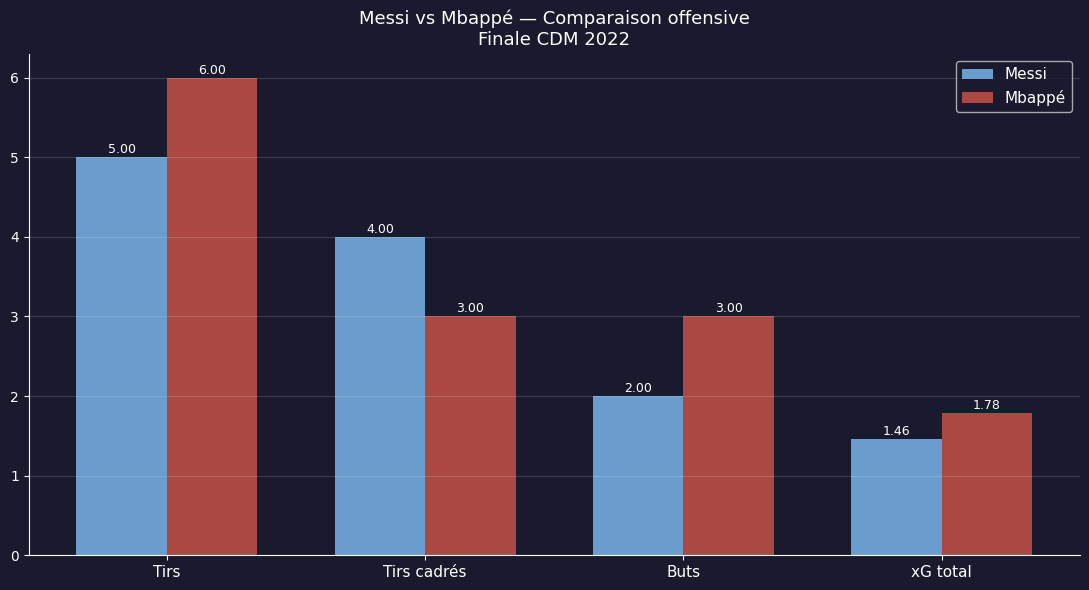

In [4]:

# ============================================================
# 2) HOOK — MESSI VS MBAPPÉ
# ============================================================
messi_stats  = stats_tirs[stats_tirs["player"] == messi_full].iloc[0]
mbappe_stats = stats_tirs[stats_tirs["player"] == mbappe_full].iloc[0]

categories = ["Tirs", "Tirs cadrés", "Buts", "xG total"]
messi_vals  = [messi_stats["tirs"], messi_stats["tirs_cadres"],
               messi_stats["buts"], messi_stats["xg_total"]]
mbappe_vals = [mbappe_stats["tirs"], mbappe_stats["tirs_cadres"],
               mbappe_stats["buts"], mbappe_stats["xg_total"]]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars1 = ax.bar(x - width/2, messi_vals,  width,
               label="Messi",  color="#74ACDF", alpha=0.9)
bars2 = ax.bar(x + width/2, mbappe_vals, width,
               label="Mbappé", color="#ba4f45", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(categories, color="white", fontsize=11)
ax.tick_params(colors="white")
ax.set_title("Messi vs Mbappé — Comparaison offensive\nFinale CDM 2022",
             color="white", fontsize=13)
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=11)
ax.grid(axis="y", alpha=0.15, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f"{bar.get_height():.2f}",
            ha="center", color="white", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f"{bar.get_height():.2f}",
            ha="center", color="white", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/messi_mbappe_comparison.png",
            dpi=150, facecolor='#1a1a2e')
plt.show()


## 2. xG par tir et issue des actions : Messi vs Mbappé

Cette visualisation précise le **timing** de leur influence. **Messi** intervient plus tôt et plus régulièrement : ses tirs s’insèrent dans plusieurs temps forts argentins, ce qui colle avec la domination progressive observée dans le `02`. **Mbappé**, lui, entre plus tard dans la feuille de tir, mais ses interventions correspondent presque toutes à des moments de rupture.

Les chiffres résument bien cette différence : Messi prend ses cinq tirs entre la 22e et la 107e minute, alors que Mbappé concentre l’essentiel de son impact entre la **70e et la 117e**. On retrouve donc à l’échelle individuelle la lecture temporelle du match : l’Argentine construit avant, la France frappe fort plus tard.

Cette figure ne dit pas seulement qui a le plus pesé, mais **comment**. Messi diffuse son influence dans la durée ; Mbappé maximise quelques fenêtres très courtes avec une brutalité offensive exceptionnelle.


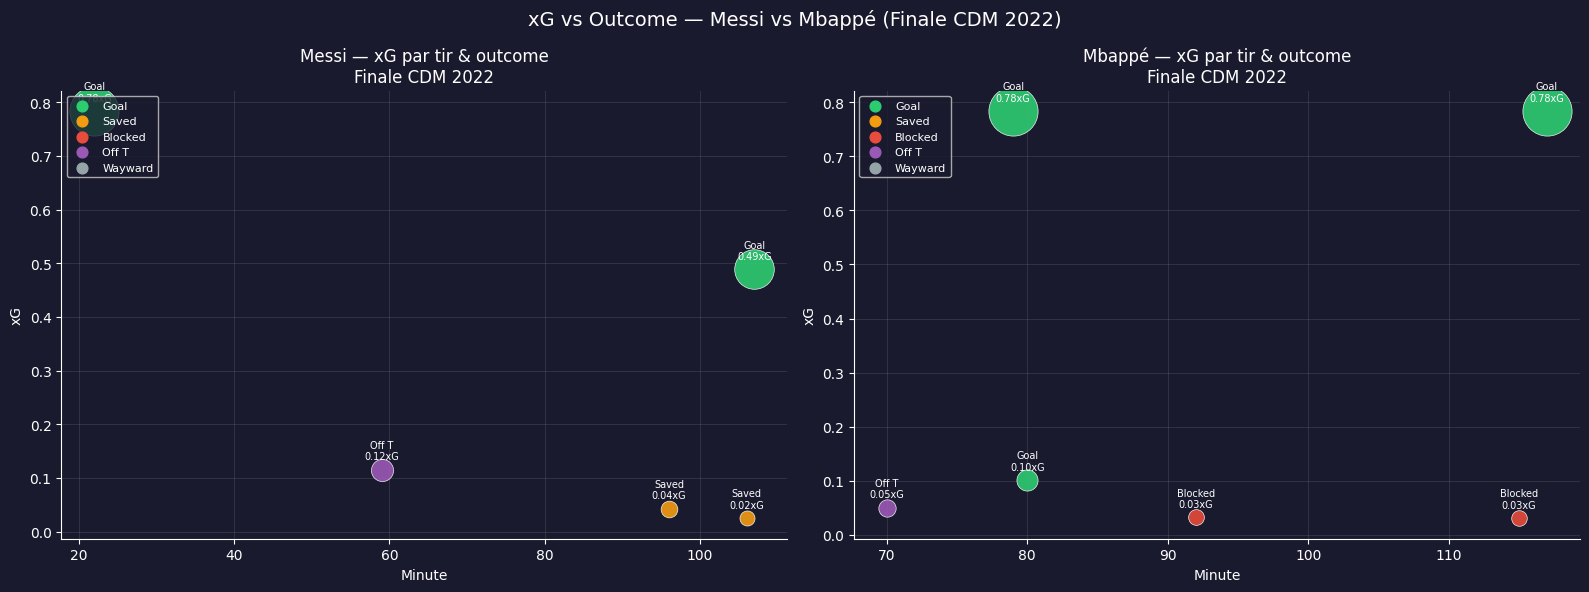

In [5]:

messi_shots_df  = shots[shots["player"] == messi_full].copy().reset_index(drop=True)
mbappe_shots_df = shots[shots["player"] == mbappe_full].copy().reset_index(drop=True)

outcome_colors = {
    "Goal":    "#2ecc71",
    "Saved":   "#f39c12",
    "Blocked": "#e74c3c",
    "Off T":   "#9b59b6",
    "Wayward": "#95a5a6",
}

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.set_facecolor('#1a1a2e')

for ax, player_df, name in zip(
    axs,
    [messi_shots_df, mbappe_shots_df],
    ["Messi", "Mbappé"]
):
    ax.set_facecolor('#1a1a2e')

    for _, row in player_df.iterrows():
        outcome = row["shot_outcome"]
        color   = outcome_colors.get(outcome, "#bdc3c7")
        ax.scatter(row["minute"], row["shot_statsbomb_xg"],
                   s=row["shot_statsbomb_xg"] * 1500 + 80,
                   color=color, edgecolors="white",
                   linewidth=0.5, alpha=0.9, zorder=3)
        ax.annotate(f"{outcome}\n{row['shot_statsbomb_xg']:.2f}xG",
                    (row["minute"], row["shot_statsbomb_xg"]),
                    fontsize=7, color="white",
                    ha="center", va="bottom",
                    xytext=(0, 6), textcoords="offset points")

    ax.set_xlabel("Minute", color="white")
    ax.set_ylabel("xG", color="white")
    ax.set_title(f"{name} — xG par tir & outcome\nFinale CDM 2022",
                 color="white", fontsize=12)
    ax.tick_params(colors="white")
    ax.grid(alpha=0.1, color="white")
    ax.spines["bottom"].set_color("white")
    ax.spines["left"].set_color("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for outcome, color in outcome_colors.items():
        ax.scatter([], [], color=color, label=outcome, s=60)
    ax.legend(facecolor='#1a1a2e', labelcolor='white',
              fontsize=8, loc="upper left")

plt.suptitle("xG vs Outcome — Messi vs Mbappé (Finale CDM 2022)",
             color="white", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/figures/xg_outcome_messi_mbappe.png",
            dpi=150, facecolor='#1a1a2e', bbox_inches="tight")
plt.show()


## 3. Activité spatiale : deux influences très différentes

La carte d’activité confirme que les deux stars ne jouent pas le même match.

**Messi** touche des ballons dans une zone beaucoup plus large, avec un ancrage marqué dans le demi-espace droit et l’axe. Il descend plus bas, se rend disponible et relie les séquences cela explique ça participation  à la création, à la circulation et à l’orientation du jeu argentin.


**Mbappé**, au contraire, évolue beaucoup plus haut et plus excentré à gauche dans l'aile. Sa présence est moins diffuse, mais plus directement orientée vers les zones où la France peut créer une accélération ou une finition rapide.

C’est exactement ce que l'analyse des deux équipes suggérait déjà : Messi épouse la logique de maîtrise argentine, tandis que Mbappé porte la logique de rupture française.


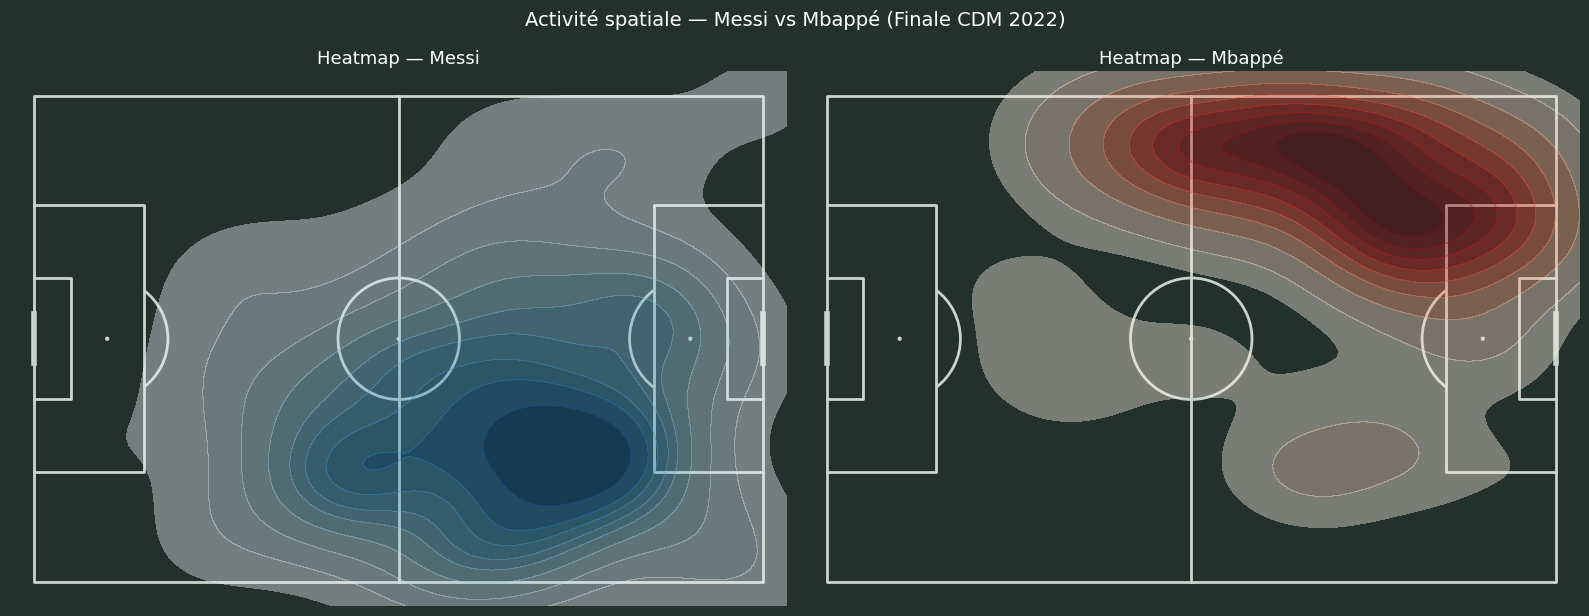

In [6]:

messi_events  = events[events["player"] == messi_full].copy()
mbappe_events = events[events["player"] == mbappe_full].copy()

pitch = Pitch(pitch_type="statsbomb", pitch_color="#22312b", line_color="#c7d5cc")
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.set_facecolor('#22312b')

for ax, ev, name, cmap in zip(
    axs,
    [messi_events, mbappe_events],
    ["Messi", "Mbappé"],
    ["Blues", "Reds"]
):
    pitch.draw(ax=ax)
    sns.kdeplot(x=ev["x"], y=ev["y"],
                fill=True, cmap=cmap, alpha=0.4, ax=ax)
    ax.set_title(f"Heatmap — {name}", color="white", fontsize=13)

plt.suptitle("Activité spatiale — Messi vs Mbappé (Finale CDM 2022)",
             color="white", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/heatmap_messi_mbappe.png",
            dpi=150, facecolor='#22312b', bbox_inches="tight")
plt.show()


## 4. Shot map : des zones de finition proches, mais des usages différents

Les deux joueurs concluent dans des zones dangereuses, mais leur shot map ne raconte pas la même histoire. **Messi**(1 penalty) tire depuis des positions légèrement plus variées et accompagne souvent une séquence déjà construite. **Mbappé**(2 penalties) apparaît plus directement tourné vers la finition, avec des tirs concentrés dans des zones d’impact immédiat.

Le contraste tient aussi à la nature des actions. Chez Messi, on lit un mélange entre présence dans la surface et retours dans la circulation avant la finition. Chez Mbappé, la carte est plus verticale et plus abrupte, ce qui renvoie bien aux séquences françaises les plus violentes du match.

On passe donc ici du “où” au “pourquoi” : la proximité des zones de tir ne signifie pas identité de rôle. Les figures suivantes vont montrer que la différence la plus forte se situe en amont, dans la zone d’influence et la participation au jeu.


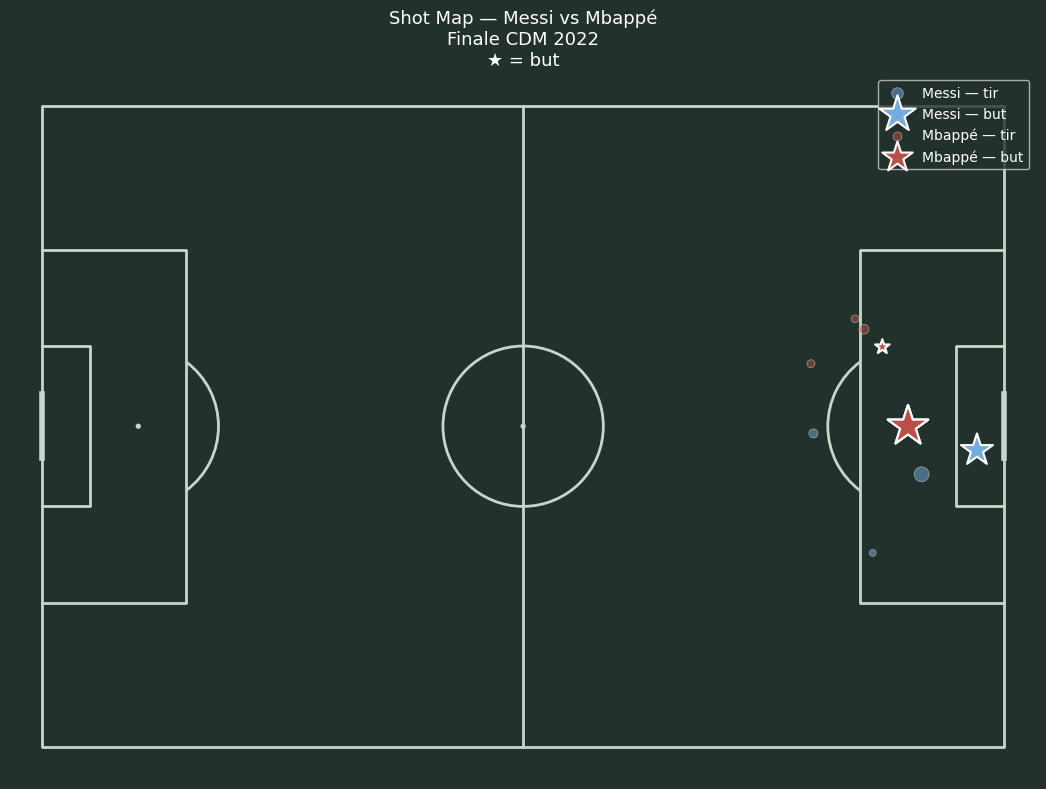

In [7]:

messi_shots  = shots[shots["player"] == messi_full].copy()
mbappe_shots = shots[shots["player"] == mbappe_full].copy()

pitch = Pitch(pitch_type="statsbomb",
              pitch_color="#22312b", line_color="#c7d5cc")
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#22312b')

for player_shots, color, label in zip(
    [messi_shots, mbappe_shots],
    ["#74ACDF", "#ba4f45"],
    ["Messi", "Mbappé"]
):
    goal_mask = player_shots["shot_outcome"] == "Goal"

    pitch.scatter(player_shots[~goal_mask]["x"],
                  player_shots[~goal_mask]["y"],
                  s=player_shots[~goal_mask]["shot_statsbomb_xg"] * 1000,
                  color=color, alpha=0.5,
                  edgecolors="white", linewidth=0.5,
                  ax=ax, label=f"{label} — tir")

    pitch.scatter(player_shots[goal_mask]["x"],
                  player_shots[goal_mask]["y"],
                  s=player_shots[goal_mask]["shot_statsbomb_xg"] * 1200,
                  color=color, alpha=1.0,
                  edgecolors="white", linewidth=1.5,
                  marker="*", ax=ax, label=f"{label} — but")

ax.legend(facecolor='#22312b', labelcolor='white', fontsize=10)
ax.set_title("Shot Map — Messi vs Mbappé\nFinale CDM 2022\n★ = but",
             color="white", fontsize=13)

plt.savefig("../reports/figures/shotmap_messi_mbappe.png",
            dpi=150, facecolor='#22312b', bbox_inches="tight")
plt.show()


## 5. Zone d’influence : Messi plus libre, Mbappé plus terminal

Le convex hull synthétise la liberté de mouvement des deux joueurs. **Messi** couvre une surface plus large, plus basse et plus intérieure, ce qui traduit un rôle hybride entre création, liaison et finition. **Mbappé** occupe une zone plus resserrée, plus haute et davantage tournée vers la profondeur.

Quand l’Argentine contrôle le match, ce n’est pas seulement grâce à son milieu : c’est aussi parce que Messi participe lui-même à cette continuité. À l’inverse, Mbappé concentre une mission plus directement offensive, cohérente avec une France moins dominante dans la construction.

Les deux planches suivantes vont prolonger ce contraste avec une vue solo sur la relation entre zone d’influence, volume de passes et production de tirs.


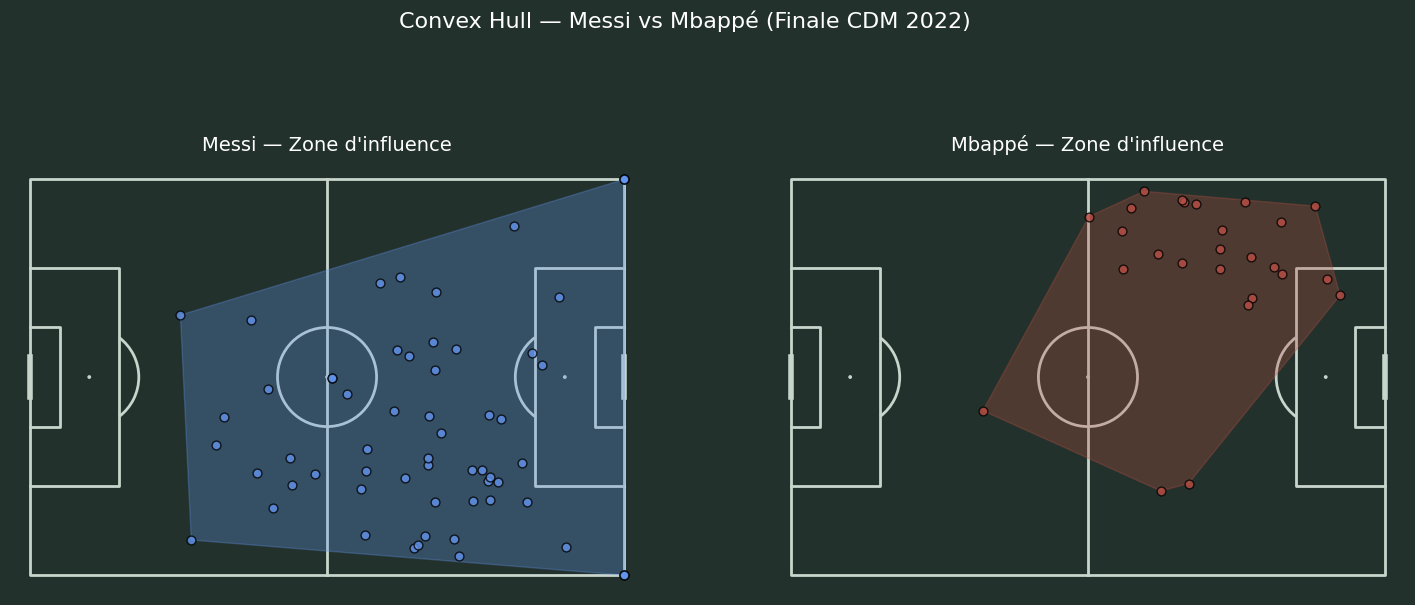

In [8]:
messi_pass = events[
    (events["type"] == "Pass")
    & (events["player"] == messi_full)
    & (events["pass_type"] != "Throw-in")
].copy()
mbappe_pass = events[
    (events["type"] == "Pass")
    & (events["player"] == mbappe_full)
    & (events["pass_type"] != "Throw-in")
].copy()

fig, axs = plt.subplots(1, 2, figsize=(18, 7))
fig.set_facecolor("#22312b")

for ax, player_pass, name, color in zip(
    axs,
    [messi_pass, mbappe_pass],
    ["Messi", "Mbappé"],
    ["cornflowerblue", "#ba4f45"],
):
    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#22312b",
        line_color="#c7d5cc",
    )
    pitch.draw(ax=ax)

    player_pass = player_pass.dropna(subset=["x", "y"])

    if len(player_pass) > 2:
        hull = pitch.convexhull(player_pass["x"], player_pass["y"])
        pitch.polygon(
            hull,
            ax=ax,
            edgecolor=color,
            facecolor=color,
            alpha=0.3,
        )

    pitch.scatter(
        player_pass["x"],
        player_pass["y"],
        ax=ax,
        edgecolor="black",
        facecolor=color,
        s=40,
        alpha=0.8,
    )

    ax.set_title(f"{name} — Zone d'influence", fontsize=14, color="white")

plt.suptitle(
    "Convex Hull — Messi vs Mbappé (Finale CDM 2022)",
    fontsize=16,
    color="white",
    y=1.02,
)
plt.savefig(
    "../reports/figures/convexhull_messi_mbappe.png",
    dpi=150,
    facecolor="#22312b",
    bbox_inches="tight",
)
plt.show()


## 6. Messi : continuité de jeu et présence décisive

Le profil individuel de Messi résume bien la logique argentine. Il cumule **60 passes** et **5 tirs**, ce qui montre qu’il ne vit pas seulement dans les derniers mètres. Sa zone d’action est large, et ses interventions offensives apparaissent comme l’aboutissement d’une présence déjà forte dans la circulation.

Cette double lecture est importante : Messi n’est pas uniquement le joueur qui conclut, il est aussi l’un des joueurs qui rendent possible la continuité des séquences. Cela rejoint directement l’image d’une Argentine plus propre dans la passe, mieux structurée au milieu et plus capable de rejouer après récupération.




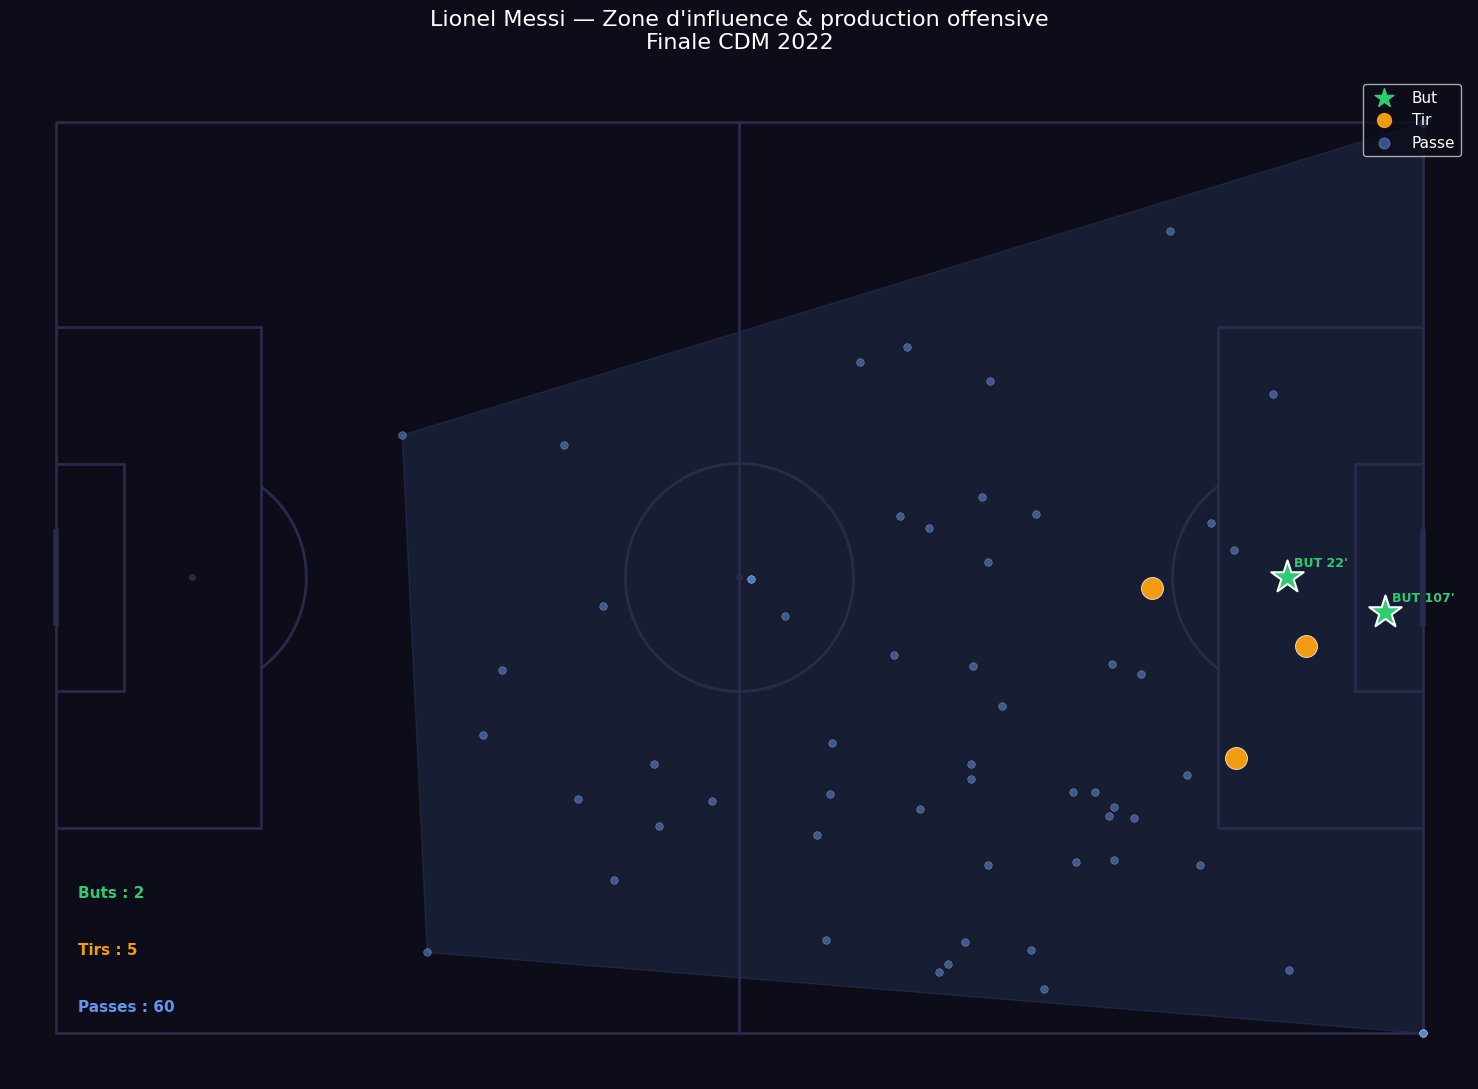

In [9]:
messi_pass_ch = events[
    (events["type"] == "Pass")
    & (events["player"] == messi_full)
    & (events["pass_type"] != "Throw-in")
].copy()
messi_shots_ch = events[
    (events["type"] == "Shot")
    & (events["player"] == messi_full)
].copy()

messi_pass_ch = messi_pass_ch.dropna(subset=["x", "y"])
messi_shots_ch = messi_shots_ch.dropna(subset=["x", "y"])

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#0d0d1a",
    line_color="#2a2a4a",
    line_zorder=2,
)

fig, ax = pitch.draw(figsize=(16, 11))
fig.set_facecolor("#0d0d1a")

if len(messi_pass_ch) > 2:
    hull = pitch.convexhull(messi_pass_ch["x"], messi_pass_ch["y"])
    pitch.polygon(
        hull,
        ax=ax,
        edgecolor="cornflowerblue",
        facecolor="cornflowerblue",
        alpha=0.12,
        zorder=1,
    )

pitch.scatter(
    messi_pass_ch["x"],
    messi_pass_ch["y"],
    ax=ax,
    s=30,
    facecolor="cornflowerblue",
    edgecolors="white",
    linewidth=0.3,
    alpha=0.5,
    zorder=3,
)

for _, row in messi_shots_ch.iterrows():
    is_goal = row.get("shot_outcome") == "Goal"
    pitch.scatter(
        row["x"],
        row["y"],
        ax=ax,
        s=600 if is_goal else 250,
        facecolor="#2ecc71" if is_goal else "#f39c12",
        edgecolors="white",
        linewidth=1.5 if is_goal else 0.5,
        marker="*" if is_goal else "o",
        alpha=1.0,
        zorder=5,
    )
    if is_goal:
        ax.annotate(
            f"BUT {int(row['minute'])}'",
            (row["x"], row["y"]),
            fontsize=9,
            color="#2ecc71",
            weight="bold",
            xytext=(5, 8),
            textcoords="offset points",
        )

ax.set_title(
    "Lionel Messi — Zone d'influence & production offensive\nFinale CDM 2022",
    color="white",
    fontsize=16,
    pad=20,
)

ax.text(2, 78, f"Passes : {len(messi_pass_ch)}", color="cornflowerblue", fontsize=11, weight="bold")
ax.text(2, 73, f"Tirs : {len(messi_shots_ch)}", color="#f39c12", fontsize=11, weight="bold")
ax.text(
    2,
    68,
    f"Buts : {(messi_shots_ch['shot_outcome'] == 'Goal').sum()}",
    color="#2ecc71",
    fontsize=11,
    weight="bold",
)

goal_dot = plt.scatter([], [], marker="*", color="#2ecc71", s=200, label="But")
shot_dot = plt.scatter([], [], marker="o", color="#f39c12", s=100, label="Tir")
pass_dot = plt.scatter([], [], marker="o", color="cornflowerblue", s=60, alpha=0.5, label="Passe")
ax.legend(
    handles=[goal_dot, shot_dot, pass_dot],
    facecolor="#0d0d1a",
    labelcolor="white",
    fontsize=11,
    loc="upper right",
)

plt.savefig(
    "../reports/figures/convexhull_messi_solo.png",
    dpi=150,
    facecolor="#0d0d1a",
    bbox_inches="tight",
)
plt.show()


## 7. Mbappé : moins de volume de jeu, plus de violence offensive

Le profil de Mbappé est presque symétrique. Avec **27 passes** et **6 tirs**, son activité est moins diffuse que celle de Messi, mais beaucoup plus directement orientée vers la finition et le déséquilibre. Son rôle n’est pas de stabiliser la France dans la possession ; il est d’attaquer les espaces et de faire basculer une séquence en quelques touches.

la France produisait moins de volume mais un danger moyen plus élevé par tir. Mbappé concentre cette logique à lui seul : moins de continuité, mais un rendement offensif énorme lorsque la France parvient enfin à l’activer.

Les sections suivantes vont élargir le regard au reste des joueurs pour voir si cette opposition Messi / Mbappé se retrouve aussi dans la distribution collective du danger.


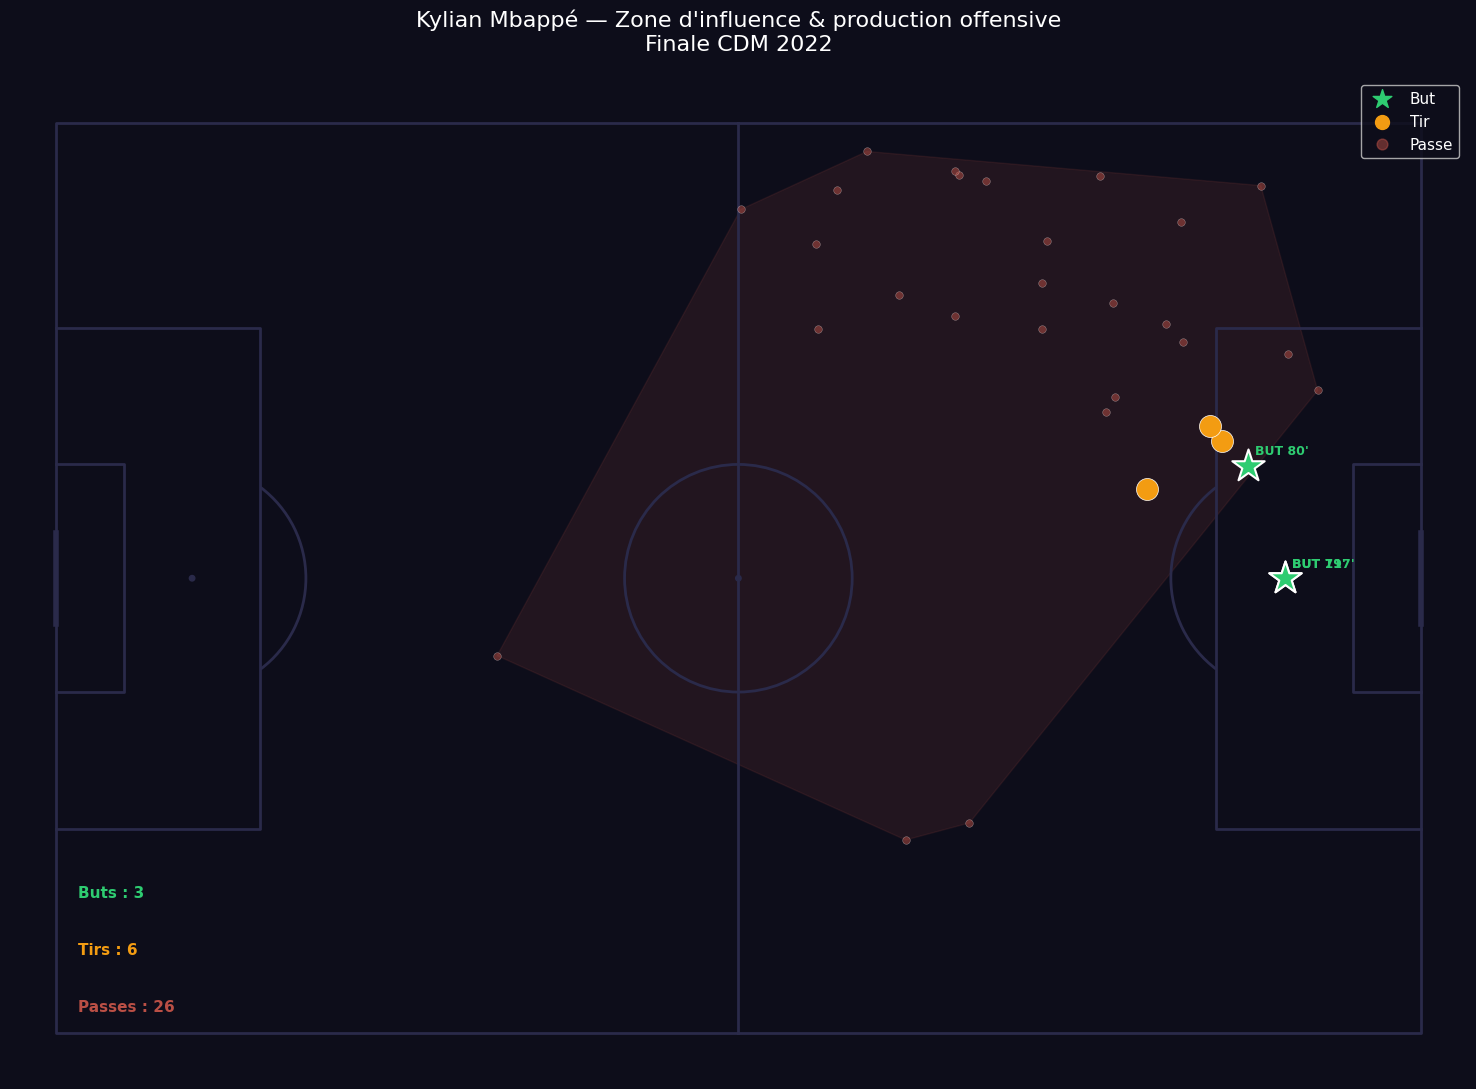

In [10]:
mbappe_pass_ch = events[
    (events["type"] == "Pass")
    & (events["player"] == mbappe_full)
    & (events["pass_type"] != "Throw-in")
].copy()
mbappe_shots_ch = events[
    (events["type"] == "Shot")
    & (events["player"] == mbappe_full)
].copy()

mbappe_pass_ch = mbappe_pass_ch.dropna(subset=["x", "y"])
mbappe_shots_ch = mbappe_shots_ch.dropna(subset=["x", "y"])

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#0d0d1a",
    line_color="#2a2a4a",
    line_zorder=2,
)

fig, ax = pitch.draw(figsize=(16, 11))
fig.set_facecolor("#0d0d1a")

if len(mbappe_pass_ch) > 2:
    hull = pitch.convexhull(mbappe_pass_ch["x"], mbappe_pass_ch["y"])
    pitch.polygon(
        hull,
        ax=ax,
        edgecolor="#ba4f45",
        facecolor="#ba4f45",
        alpha=0.12,
        zorder=1,
    )

pitch.scatter(
    mbappe_pass_ch["x"],
    mbappe_pass_ch["y"],
    ax=ax,
    s=30,
    facecolor="#ba4f45",
    edgecolors="white",
    linewidth=0.3,
    alpha=0.5,
    zorder=3,
)

for _, row in mbappe_shots_ch.iterrows():
    is_goal = row.get("shot_outcome") == "Goal"
    pitch.scatter(
        row["x"],
        row["y"],
        ax=ax,
        s=600 if is_goal else 250,
        facecolor="#2ecc71" if is_goal else "#f39c12",
        edgecolors="white",
        linewidth=1.5 if is_goal else 0.5,
        marker="*" if is_goal else "o",
        alpha=1.0,
        zorder=5,
    )
    if is_goal:
        ax.annotate(
            f"BUT {int(row['minute'])}'",
            (row["x"], row["y"]),
            fontsize=9,
            color="#2ecc71",
            weight="bold",
            xytext=(5, 8),
            textcoords="offset points",
        )

ax.set_title(
    "Kylian Mbappé — Zone d'influence & production offensive\nFinale CDM 2022",
    color="white",
    fontsize=16,
    pad=20,
)

ax.text(2, 78, f"Passes : {len(mbappe_pass_ch)}", color="#ba4f45", fontsize=11, weight="bold")
ax.text(2, 73, f"Tirs : {len(mbappe_shots_ch)}", color="#f39c12", fontsize=11, weight="bold")
ax.text(
    2,
    68,
    f"Buts : {(mbappe_shots_ch['shot_outcome'] == 'Goal').sum()}",
    color="#2ecc71",
    fontsize=11,
    weight="bold",
)

goal_dot = plt.scatter([], [], marker="*", color="#2ecc71", s=200, label="But")
shot_dot = plt.scatter([], [], marker="o", color="#f39c12", s=100, label="Tir")
pass_dot = plt.scatter([], [], marker="o", color="#ba4f45", s=60, alpha=0.5, label="Passe")
ax.legend(
    handles=[goal_dot, shot_dot, pass_dot],
    facecolor="#0d0d1a",
    labelcolor="white",
    fontsize=11,
    loc="upper right",
)

plt.savefig(
    "../reports/figures/convexhull_mbappe_solo.png",
    dpi=150,
    facecolor="#0d0d1a",
    bbox_inches="tight",
)
plt.show()


## 8. Production offensive des deux équipes

Cette vue d’ensemble reconnecte le focus joueurs au récit collectif . l’Argentine garde un avantage de **volume** avec **20 tirs pour 2.76 xG**, contre **10 tirs pour 2.27 xG** à la France. La différence visible sur la carte est que ce volume argentin se répartit sur plusieurs profils, alors que la production française remonte beaucoup plus vite vers quelques joueurs-clés.

Côté argentin, Messi reste le moteur principal, mais il est accompagné par **Lautaro Martínez**, **Di María**, **Mac Allister**, **Enzo** ou **De Paul**. Côté français, la hiérarchie est plus verticale : **Mbappé** absorbe la majeure partie de la finition, avec **Kolo Muani** comme relais tardif mais très dangereux.



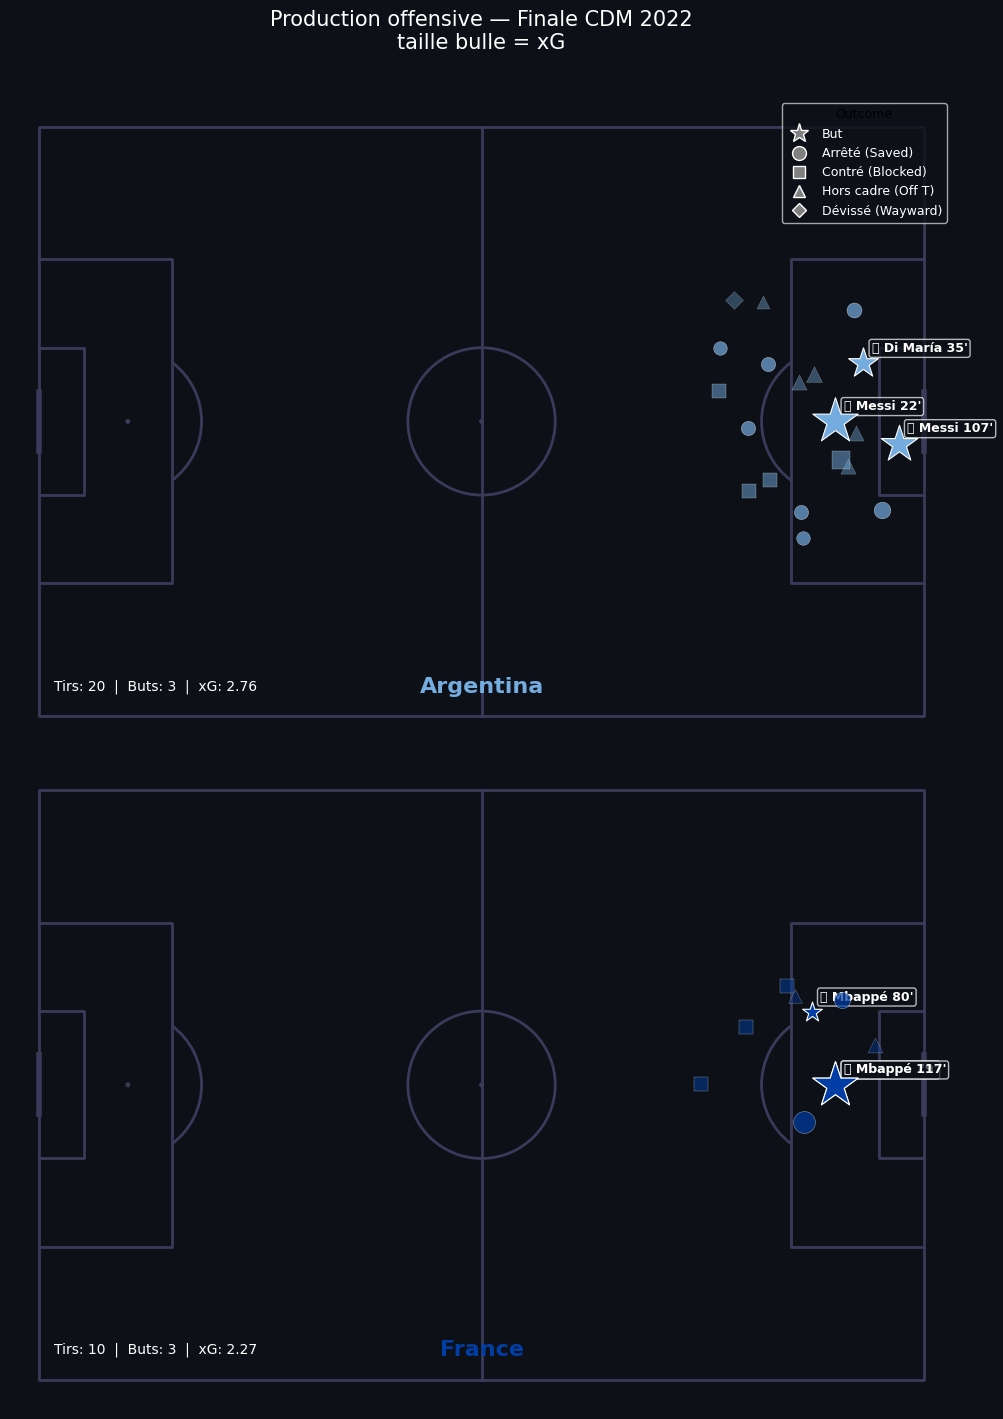

In [11]:
# ============================================================
# 3) OFFENSIVE OVERVIEW — TEAM + PLAYERS
# ============================================================
shots_display = events[events["type"] == "Shot"].copy()
shots_display["player_short"] = shots_display["player"]

outcome_marker = {
    "Goal": ("*", 1.0, 1400),
    "Saved": ("o", 0.7, 600),
    "Blocked": ("s", 0.5, 400),
    "Off T": ("^", 0.4, 350),
    "Wayward": ("D", 0.35, 300),
}

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#0d1117",
    line_color="#3a3a5a",
    line_zorder=2,
)

fig, axs = plt.subplots(2, 1, figsize=(16, 14))
fig.set_facecolor("#0d1117")

for ax, team, color in zip(
    axs,
    ["Argentina", "France"],
    ["#74ACDF", "#003DA5"],
):
    pitch.draw(ax=ax)
    ax.set_facecolor("#0d1117")

    team_shots = shots_display[shots_display["team"] == team]

    for _, row in team_shots.iterrows():
        outcome = row["shot_outcome"]
        marker, alpha, base_size = outcome_marker.get(outcome, ("o", 0.4, 300))
        size = row["shot_statsbomb_xg"] * base_size + 80

        ax.scatter(
            row["x"],
            row["y"],
            s=size,
            color=color,
            alpha=alpha,
            edgecolors="white",
            linewidth=0.8 if outcome == "Goal" else 0.3,
            marker=marker,
            zorder=4 if outcome == "Goal" else 3,
        )

        if outcome == "Goal":
            ax.annotate(
                f"⚽ {row['player_short']} {int(row['minute'])}'",
                (row["x"], row["y"]),
                fontsize=9,
                color="white",
                weight="bold",
                ha="left",
                va="bottom",
                xytext=(6, 6),
                textcoords="offset points",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    facecolor="#0d1117",
                    edgecolor="white",
                    alpha=0.7,
                ),
            )

    n_tirs = len(team_shots)
    n_buts = (team_shots["shot_outcome"] == "Goal").sum()
    xg_tot = team_shots["shot_statsbomb_xg"].sum()

    ax.text(60, 76, team, ha="center", va="center", color=color, fontsize=16, weight="bold")
    ax.text(2, 76, f"Tirs: {n_tirs}  |  Buts: {n_buts}  |  xG: {xg_tot:.2f}", color="white", fontsize=10, va="center")

legend_elements = [
    Line2D([0], [0], marker="*", color="w", markerfacecolor="grey", markersize=14, label="But", linestyle="None"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="grey", markersize=10, label="Arrêté (Saved)", linestyle="None"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="grey", markersize=8, label="Contré (Blocked)", linestyle="None"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="grey", markersize=8, label="Hors cadre (Off T)", linestyle="None"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="grey", markersize=7, label="Dévissé (Wayward)", linestyle="None"),
]
axs[0].legend(
    handles=legend_elements,
    facecolor="#0d1117",
    labelcolor="white",
    fontsize=9,
    loc="upper right",
    title="Outcome",
    title_fontsize=9,
)

plt.suptitle("Production offensive — Finale CDM 2022\ntaille bulle = xG", color="white", fontsize=15, y=1.01)

plt.tight_layout()
plt.savefig(
    "../reports/figures/shotmap_production_offensive.png",
    dpi=150,
    facecolor="#0d1117",
    bbox_inches="tight",
)
plt.show()


## 9. Tirs vs xG : qui a le plus pesé offensivement ?

Le nuage de points permet de distinguer trois types de profils. D’abord les deux leaders : **Mbappé** domine en xG total et en buts, tandis que **Messi** combine presque autant de danger avec une meilleure précision. Ensuite, des joueurs de soutien comme **Lautaro Martínez** ou **Di María**, qui prolongent la menace argentine. Enfin, des profils d’impact comme **Kolo Muani**, capables de produire beaucoup de danger avec peu de tirs.

La différence entre les deux équipes se lit très bien ici. Chez les Français, la dépendance à Mbappé saute aux yeux. Chez les Argentins, la menace reste portée par Messi, mais elle ne s’arrête pas à lui.

On retrouve donc, à l’échelle individuelle, ce que le notebook `02` disait à l’échelle collective : la France dispose d’un levier offensif extrêmement puissant, tandis que l’Argentine présente un éventail plus large de sources de danger.


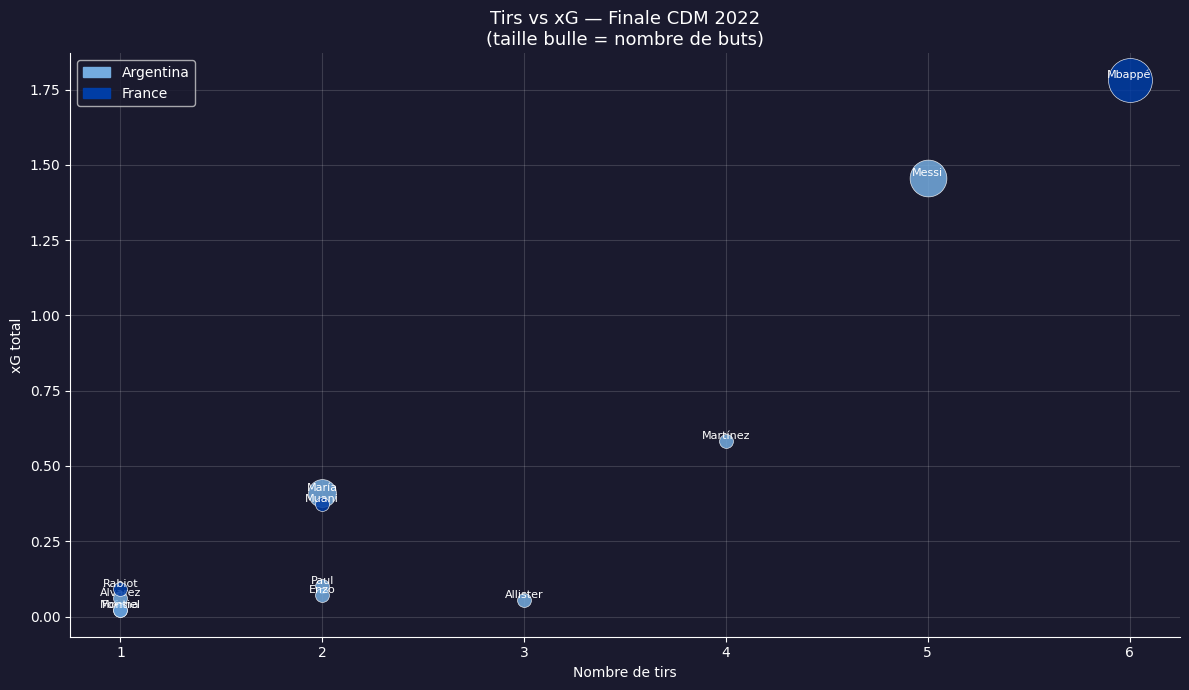

In [12]:

fig, ax = plt.subplots(figsize=(12, 7))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

for _, row in stats_tirs.iterrows():
    color = "#003DA5" if row["team"] == "France" else "#74ACDF"
    ax.scatter(row["tirs"], row["xg_total"],
               s=row["buts"] * 300 + 100,
               color=color, alpha=0.85, zorder=3,
               edgecolors="white", linewidth=0.5)
    ax.annotate(row["player"].split()[-1],
                (row["tirs"], row["xg_total"]),
                fontsize=8, ha="center", va="bottom",
                color="white")

arg_patch = mpatches.Patch(color="#74ACDF", label="Argentina")
fra_patch = mpatches.Patch(color="#003DA5", label="France")
ax.legend(handles=[arg_patch, fra_patch],
          facecolor='#1a1a2e', labelcolor='white', fontsize=10)

ax.set_xlabel("Nombre de tirs", color="white")
ax.set_ylabel("xG total", color="white")
ax.set_title("Tirs vs xG — Finale CDM 2022\n(taille bulle = nombre de buts)",
             color="white", fontsize=13)
ax.tick_params(colors="white")
ax.grid(alpha=0.15, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../reports/figures/tirs_xg_joueurs.png", dpi=150, facecolor='#1a1a2e')
plt.show()


## 10. Top 10 xG : les joueurs les plus dangereux

Le classement du xG confirme les hiérarchies du match. **Mbappé** domine avec **1.78 xG**, devant **Messi** à **1.46**. Derrière eux, l’écart se creuse rapidement, puis on retrouve **Lautaro Martínez (0.58)**, **Di María (0.41)** et **Kolo Muani (0.37)**.

Cette répartition est très instructive. Pour la France, un seul joueur concentre une très grande partie du danger, puis un second pic apparaît plus tard avec Kolo Muani. Pour l’Argentine, Messi reste au sommet, mais il est entouré de plusieurs relais offensifs capables d’ajouter du danger à des moments différents du match.

Le prochain graphique isole justement la conversion finale, afin de distinguer les joueurs qui se sont procuré les meilleures situations de ceux qui les ont transformées.


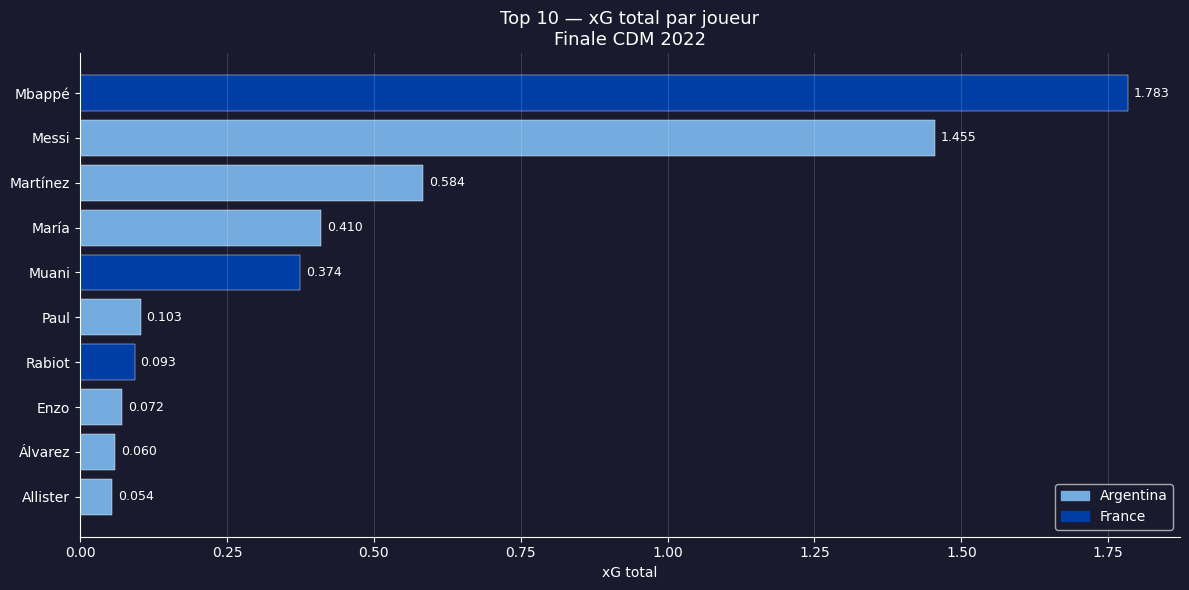

In [13]:

top_xg = stats_tirs.sort_values("xg_total", ascending=False).head(10)
colors  = ["#003DA5" if t == "France" else "#74ACDF" for t in top_xg["team"]]

fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.barh(top_xg["player"].apply(lambda x: x.split()[-1]),
               top_xg["xg_total"], color=colors, edgecolor="white",
               linewidth=0.3)

ax.set_xlabel("xG total", color="white")
ax.set_title("Top 10 — xG total par joueur\nFinale CDM 2022",
             color="white", fontsize=13)
ax.invert_yaxis()
ax.tick_params(colors="white")
ax.grid(axis="x", alpha=0.15, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, val in zip(bars, top_xg["xg_total"]):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", color="white", fontsize=9)

arg_patch = mpatches.Patch(color="#74ACDF", label="Argentina")
fra_patch = mpatches.Patch(color="#003DA5", label="France")
ax.legend(handles=[arg_patch, fra_patch],
          facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig("../reports/figures/top10_xg_joueurs.png",
            dpi=150, facecolor='#1a1a2e')
plt.show()


### Complément — Qui a concrétisé les séquences ?

Le xG mesure le danger créé, mais il ne dit pas encore **qui a effectivement transformé les occasions**. Ce graphique recentre donc la lecture sur la finition pure.

En version match-only, la hiérarchie est très nette : **Mbappé** mène avec un triplé, **Messi** suit avec un doublé, puis **Di María** ferme le podium.


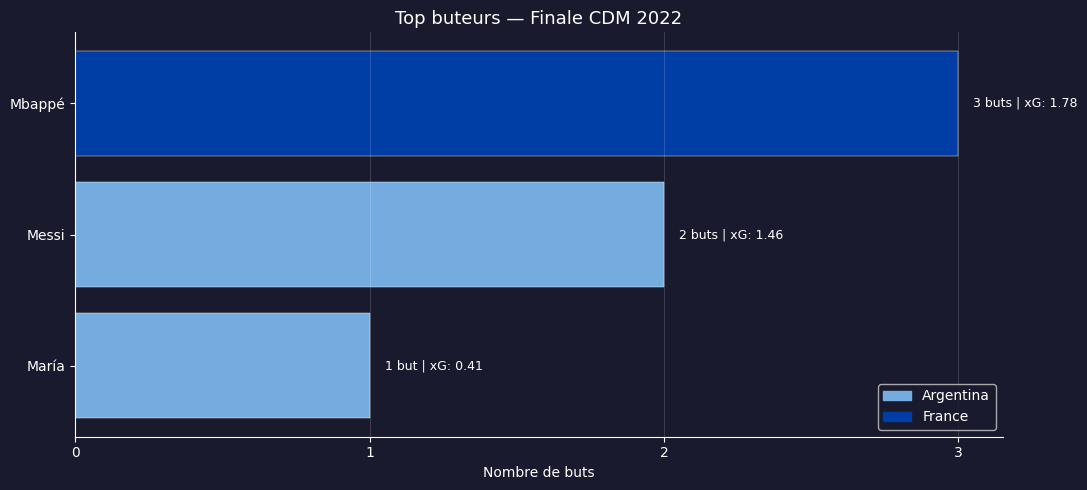

In [14]:

top_buts = stats_tirs[stats_tirs["buts"] > 0].sort_values("buts", ascending=False)
colors   = ["#003DA5" if t == "France" else "#74ACDF" for t in top_buts["team"]]

fig, ax = plt.subplots(figsize=(11, 5))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.barh(top_buts["player"].apply(lambda x: x.split()[-1]),
               top_buts["buts"], color=colors,
               edgecolor="white", linewidth=0.3)

ax.set_xlabel("Nombre de buts", color="white")
ax.set_title("Top buteurs — Finale CDM 2022",
             color="white", fontsize=13)
ax.invert_yaxis()
ax.tick_params(colors="white")
ax.grid(axis="x", alpha=0.15, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([0, 1, 2, 3])

for bar, val, xg in zip(bars, top_buts["buts"], top_buts["xg_total"]):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f"{int(val)} but{'s' if val > 1 else ''} | xG: {xg:.2f}",
            va="center", color="white", fontsize=9)

arg_patch = mpatches.Patch(color="#74ACDF", label="Argentina")
fra_patch = mpatches.Patch(color="#003DA5", label="France")
ax.legend(handles=[arg_patch, fra_patch],
          facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig("../reports/figures/top_buteurs.png",
            dpi=150, facecolor='#1a1a2e')
plt.show()


## 11. Volume de tirs : quantité, précision et finition

Cette figure rapproche la quantité de tirs de leur qualité d’exécution. **Mbappé** est le joueur qui frappe le plus (**6 tirs**), mais **Messi** est plus précis avec **80 % de tirs cadrés** contre **50 %** pour Mbappé. Cela renforce l’idée d’un profil argentin plus propre dans la sélection des situations, là où Mbappé assume un rôle de finisseur plus agressif.

On voit aussi apparaître des profils secondaires très différents. **Lautaro Martínez** prend **4 tirs** sans marquer, ce qui rappelle l’intensité offensive argentine en prolongation mais aussi une forme de déchet dans la finition. **Kolo Muani** pèse moins en volume, mais chaque tir porte beaucoup plus de tension.

Cette lecture prépare bien la section suivante : au-delà du nombre de tirs, ce sont aussi leurs issues concrètes qui séparent les joueurs.


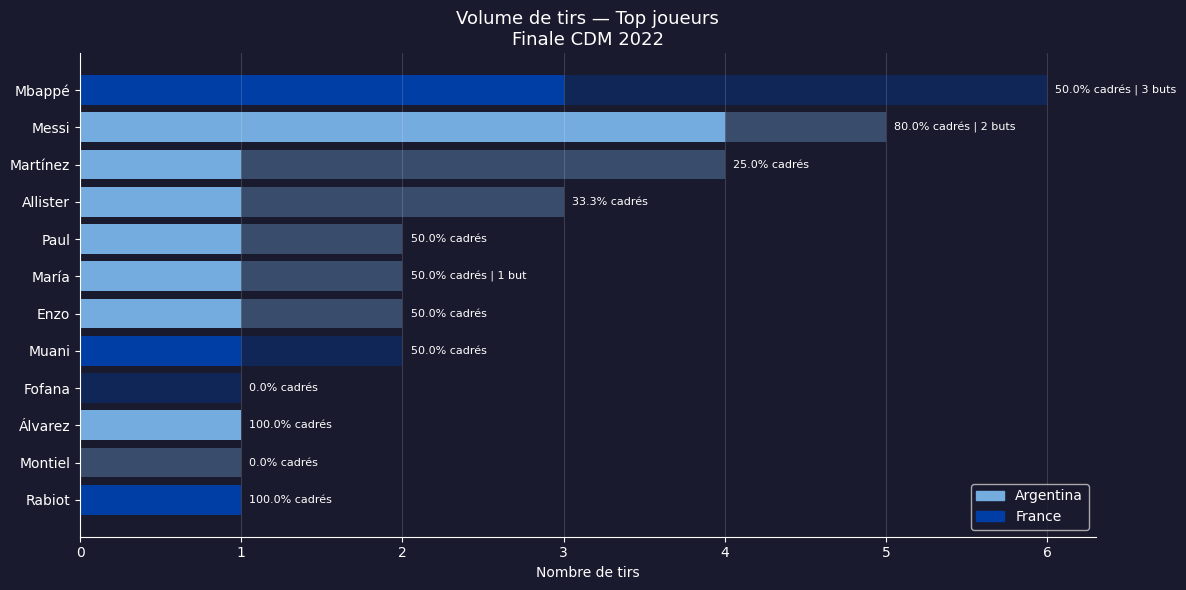

In [15]:

top_tirs = stats_tirs.sort_values("tirs", ascending=False).head(12)
colors   = ["#003DA5" if t == "France" else "#74ACDF" for t in top_tirs["team"]]

fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars_tot = ax.barh(top_tirs["player"].apply(lambda x: x.split()[-1]),
                   top_tirs["tirs"],
                   color=colors, alpha=0.35, label="Tirs totaux")
bars_cad = ax.barh(top_tirs["player"].apply(lambda x: x.split()[-1]),
                   top_tirs["tirs_cadres"],
                   color=colors, alpha=1.0, label="Tirs cadrés")

ax.set_xlabel("Nombre de tirs", color="white")
ax.set_title("Volume de tirs — Top joueurs\nFinale CDM 2022",
             color="white", fontsize=13)
ax.invert_yaxis()
ax.tick_params(colors="white")
ax.grid(axis="x", alpha=0.15, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, prec, buts in zip(bars_tot, top_tirs["precision"], top_tirs["buts"]):
    label = f"{prec}% cadrés"
    if buts > 0:
        label += f" | {int(buts)} but{'s' if buts > 1 else ''}"
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            label, va="center", color="white", fontsize=8)

arg_patch = mpatches.Patch(color="#74ACDF", label="Argentina")
fra_patch = mpatches.Patch(color="#003DA5", label="France")
ax.legend(handles=[arg_patch, fra_patch],
          facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig("../reports/figures/volume_tirs_precision.png",
            dpi=150, facecolor='#1a1a2e')
plt.show()


## 12. Profils de finition : comment les principaux tireurs concluent leurs actions

Le détail des issues de tir nuance utilement les classements précédents. **Messi** combine buts, tirs arrêtés et tentatives hors cadre dans un profil assez complet. **Mbappé** concentre lui aussi plusieurs buts, mais avec davantage de tirs contrés ou interrompus, ce qui correspond à des actions plus directes et souvent plus serrées.

Derrière eux, le graphique aide à relire les seconds rôles du match. **Lautaro Martínez** apparaît comme un volume offensif important mais imparfaitement converti. **Kolo Muani** et **Di María** illustrent au contraire des profils plus ponctuels, mais associés à des séquences très fortes du récit global.

Ce passage est important pour ne pas réduire l’analyse à “qui a le plus tiré”. La finition dépend aussi du type d’action, du contexte temporel et du rôle tactique occupé par le joueur.


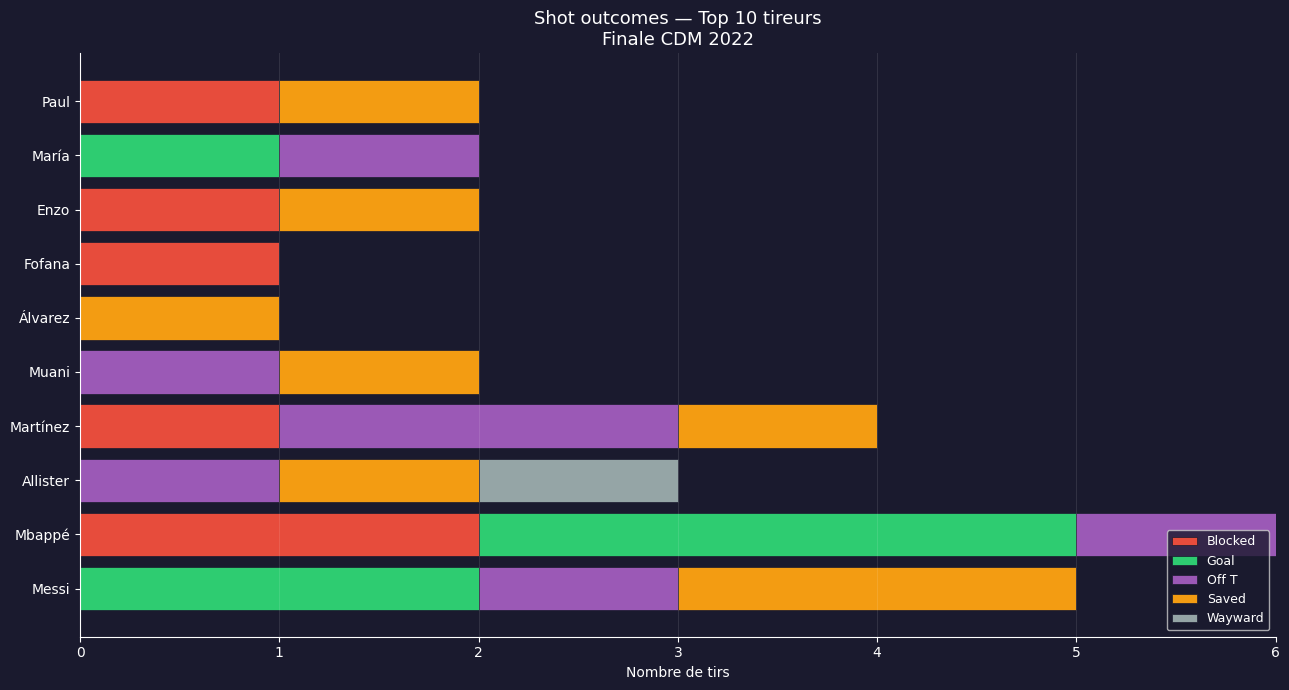

In [16]:

shots_outcomes = shots.groupby(["player","team","shot_outcome"]).size().reset_index(name="count")
top_shooters   = stats_tirs.sort_values("tirs", ascending=False).head(10)["player"].tolist()

shots_pivot = shots_outcomes[shots_outcomes["player"].isin(top_shooters)].pivot_table(
    index=["player","team"], columns="shot_outcome",
    values="count", fill_value=0
).reset_index()

outcome_cols   = [c for c in shots_pivot.columns if c not in ["player","team"]]
outcome_colors = {
    "Goal":     "#2ecc71",
    "Saved":    "#f39c12",
    "Blocked":  "#e74c3c",
    "Off T":    "#9b59b6",
    "Wayward":  "#95a5a6",
    "Post":     "#1abc9c",
}

fig, ax = plt.subplots(figsize=(13, 7))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

labels = shots_pivot["player"].apply(lambda x: x.split()[-1])
bottom = np.zeros(len(shots_pivot))

for outcome in outcome_cols:
    vals  = shots_pivot[outcome].values
    color = outcome_colors.get(outcome, "#bdc3c7")
    ax.barh(labels, vals, left=bottom, color=color,
            label=outcome, edgecolor="#1a1a2e", linewidth=0.5)
    bottom += vals

ax.set_xlabel("Nombre de tirs", color="white")
ax.set_title("Shot outcomes — Top 10 tireurs\nFinale CDM 2022",
             color="white", fontsize=13)
ax.invert_yaxis()
ax.tick_params(colors="white")
ax.grid(axis="x", alpha=0.1, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(facecolor='#1a1a2e', labelcolor='white',
          fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("../reports/figures/shot_outcomes_joueurs.png",
            dpi=150, facecolor='#1a1a2e')
plt.show()


## 13. Dribbles : qui cherche le déséquilibre en un contre un ?

Le dribble est l’un des meilleurs marqueurs de rupture dans ce match. **Mbappé** domine avec **11 dribbles tentés**, ce qui confirme son rôle central dans la recherche d’explosivité côté français. **Di María** suit avec **8 tentatives** et une bonne réussite, ce qui correspond très bien à son importance dans la première phase de domination argentine.

Cette opposition rejoint encore une fois le notebook `02`. La France a besoin de provoquer des déséquilibres forts par ses individualités, tandis que l’Argentine intègre davantage le dribble dans une structure collective déjà cohérente.

Le graphique suivant complétera cette lecture en opposant volume et efficacité, pour distinguer les joueurs qui provoquent beaucoup de un-contre-un de ceux qui les réussissent le mieux.


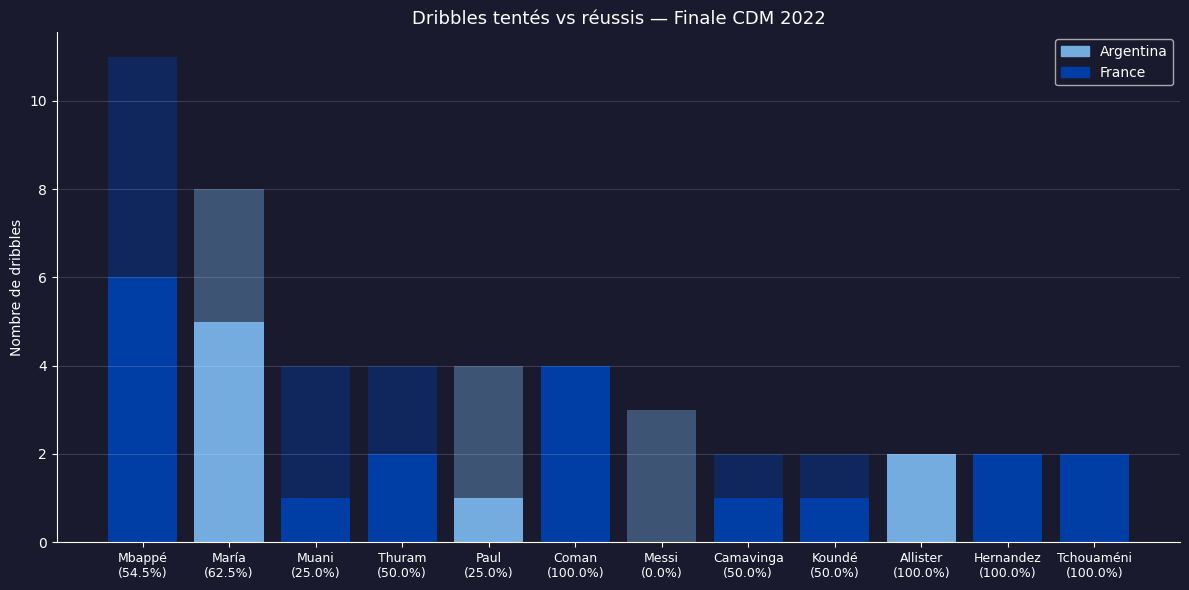

In [17]:

# ============================================================
# 4) DRIBBLES
# ============================================================
dribble_stats = events[events["type"] == "Dribble"].groupby(["player","team"]).agg(
    dribbles_tentes  = ("type", "count"),
    dribbles_reussis = ("dribble_outcome", lambda x: (x == "Complete").sum())
).reset_index()

dribble_stats["taux_reussite"] = (
    dribble_stats["dribbles_reussis"] / dribble_stats["dribbles_tentes"] * 100
).round(1)
dribble_stats = dribble_stats.sort_values("dribbles_tentes", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

colors = ["#003DA5" if t == "France" else "#74ACDF" for t in dribble_stats["team"]]
x = range(len(dribble_stats))

bars_total = ax.bar(x, dribble_stats["dribbles_tentes"],
                    color=colors, alpha=0.4, label="Tentés")
bars_reussis = ax.bar(x, dribble_stats["dribbles_reussis"],
                      color=colors, alpha=1.0, label="Réussis")

ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"{p.split()[-1]}\n({r}%)" for p, r in
     zip(dribble_stats["player"], dribble_stats["taux_reussite"])],
    color="white", fontsize=9
)
ax.tick_params(colors="white")
ax.set_ylabel("Nombre de dribbles", color="white")
ax.set_title("Dribbles tentés vs réussis — Finale CDM 2022",
             color="white", fontsize=13)
ax.grid(axis="y", alpha=0.15, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

arg_patch = mpatches.Patch(color="#74ACDF", label="Argentina")
fra_patch = mpatches.Patch(color="#003DA5", label="France")
ax.legend(handles=[arg_patch, fra_patch],
          facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig("../reports/figures/dribbles_joueurs.png", dpi=150, facecolor='#1a1a2e')
plt.show()


### Complément — Beaucoup dribbler ou bien dribbler ?

Le classement brut des dribbles ne dit pas tout. Ce second graphique oppose le **volume** et la **réussite**, ce qui permet de distinguer les vrais créateurs de rupture des joueurs simplement très sollicités dans le un-contre-un.

Dans le récit du match, cette nuance est importante : la France a davantage besoin du dribble pour casser la structure adverse, alors que l’Argentine l’utilise plus souvent comme un accélérateur à l’intérieur d’un cadre collectif déjà stable.


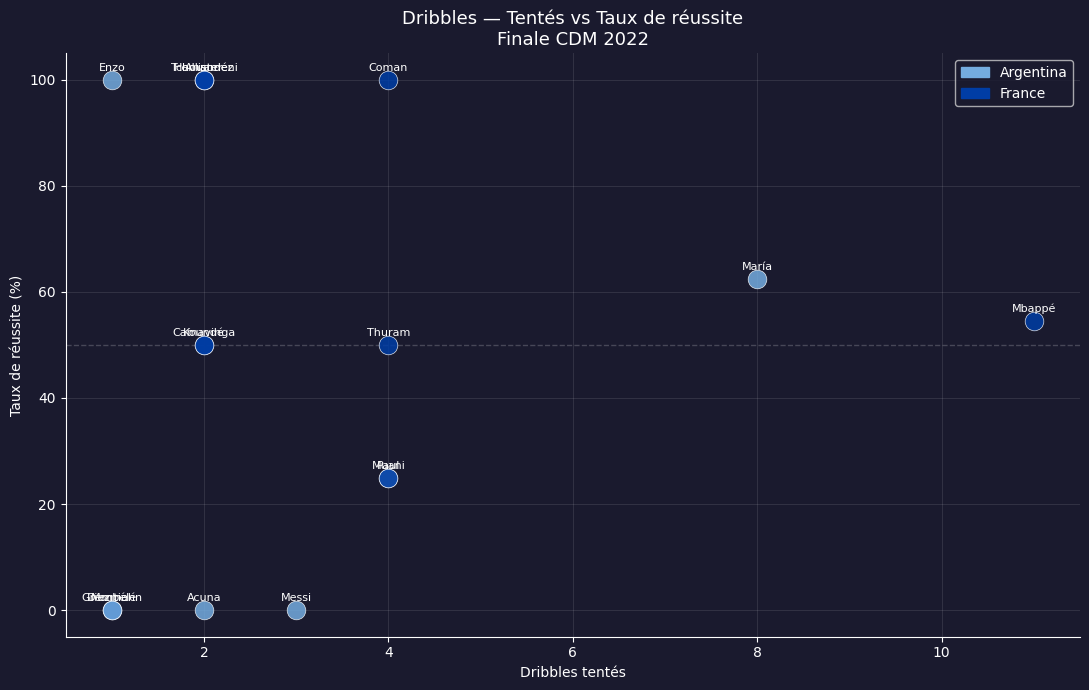

In [18]:

dribble_all = events[events["type"] == "Dribble"].groupby(["player","team"]).agg(
    dribbles_tentes  = ("type", "count"),
    dribbles_reussis = ("dribble_outcome", lambda x: (x == "Complete").sum())
).reset_index()
dribble_all["taux_reussite"] = (
    dribble_all["dribbles_reussis"] / dribble_all["dribbles_tentes"] * 100
).round(1)

fig, ax = plt.subplots(figsize=(11, 7))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

for _, row in dribble_all.iterrows():
    color = "#003DA5" if row["team"] == "France" else "#74ACDF"
    ax.scatter(row["dribbles_tentes"], row["taux_reussite"],
               s=180, color=color, alpha=0.85,
               edgecolors="white", linewidth=0.5, zorder=3)
    ax.annotate(row["player"].split()[-1],
                (row["dribbles_tentes"], row["taux_reussite"]),
                fontsize=8, color="white",
                ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points")

ax.axhline(y=50, color="white", linestyle="--", alpha=0.2, lw=1)
ax.set_xlabel("Dribbles tentés", color="white")
ax.set_ylabel("Taux de réussite (%)", color="white")
ax.set_title("Dribbles — Tentés vs Taux de réussite\nFinale CDM 2022",
             color="white", fontsize=13)
ax.tick_params(colors="white")
ax.grid(alpha=0.1, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

arg_patch = mpatches.Patch(color="#74ACDF", label="Argentina")
fra_patch = mpatches.Patch(color="#003DA5", label="France")
ax.legend(handles=[arg_patch, fra_patch],
          facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig("../reports/figures/dribbles_scatter.png",
            dpi=150, facecolor='#1a1a2e')
plt.show()


## 14. Qualité de passe : la maîtrise argentine se retrouve aussi individuellement

Les indicateurs individuels de passe prolongent très clairement les conclusions de l’analyse `02`. Côté argentin, la circulation ne repose pas uniquement sur les défenseurs : elle passe aussi beaucoup par le milieu. **Enzo Fernández** est d’ailleurs le joueur qui tente le plus de passes du match (**94**) tout en conservant un très bon taux de réussite (**84 %**). À ses côtés, **De Paul (68, 83.8 %)** et **Mac Allister (52, 86.5 %)** confirment que le cœur du jeu argentin participe pleinement à la maîtrise du ballon, tandis que **Otamendi (75, 92 %)** et **Romero (71, 84.5 %)** assurent une première relance solide.

Côté français, la hiérarchie est différente. Les joueurs qui tentent le plus de passes sont surtout des profils plus bas, comme **Tchouaméni (69, 81.2 %)**, **Koundé (67, 77.6 %)**, **Upamecano (64, 79.7 %)** et **Varane (61, 90.2 %)**. Cela suggère une circulation davantage portée par la base de l’équipe, avec moins de continuité dans le milieu et dans les zones avancées. Même lorsque les pourcentages restent bons, la structure paraît donc moins confortable et moins progressive que côté argentin.

Le cas de **Lloris (41 passes, 56.1 %)** est particulièrement révélateur et recoupe ce qu’on observait déjà sur les sorties de balle sous pression : la France a souvent été contrainte de relancer depuis l’arrière, parfois dans l’urgence, alors que l’Argentine réussissait davantage à faire vivre le ballon à travers ses milieux.

> **Insight :**  
> La supériorité argentine dans la possession se voit aussi à l’échelle des individus : chez elle, le ballon circule beaucoup et bien par les milieux, alors que côté français, la relance repose plus souvent sur les défenseurs et le gardien.


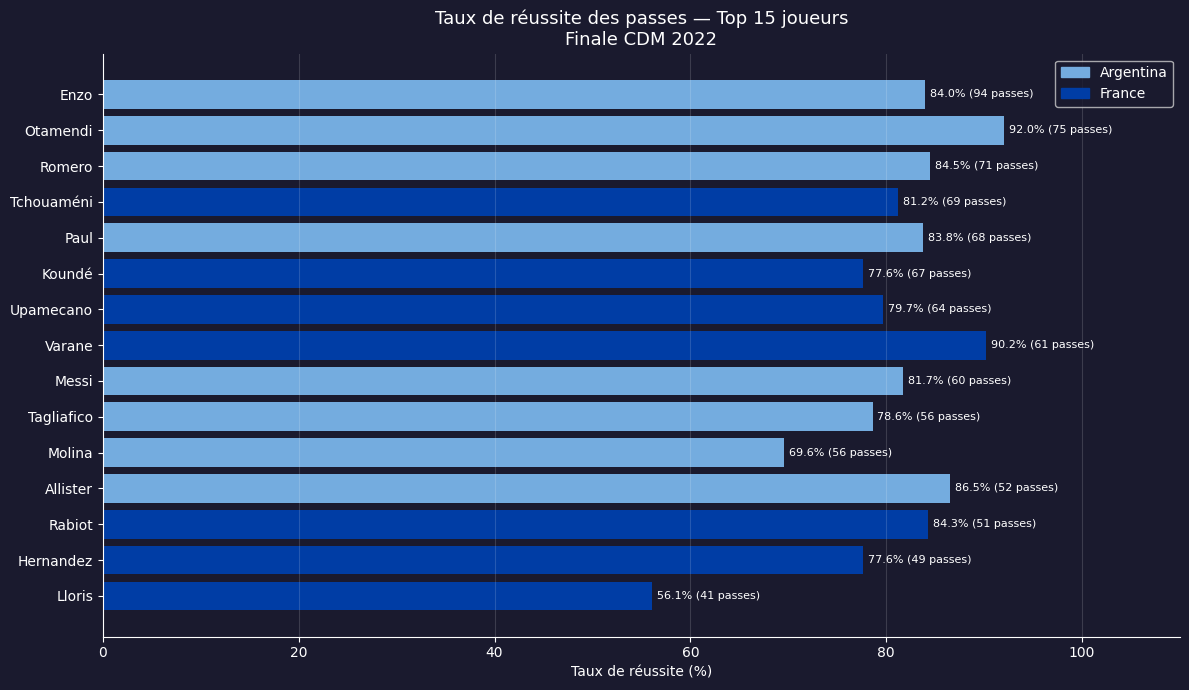

In [19]:

# ============================================================
# 5) PASSES
# ============================================================
passes = events[events["type"] == "Pass"].copy()

passes_stats = passes.groupby(["player","team"]).agg(
    passes_tentees  = ("type", "count"),
    passes_reussies = ("pass_outcome", lambda x: x.isna().sum())
).reset_index()

passes_stats["taux_passes"] = (
    passes_stats["passes_reussies"] / passes_stats["passes_tentees"] * 100
).round(1)

top_passes = passes_stats.sort_values("passes_tentees", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

colors = ["#003DA5" if t == "France" else "#74ACDF" for t in top_passes["team"]]
bars = ax.barh(top_passes["player"].apply(lambda x: x.split()[-1]),
               top_passes["taux_passes"], color=colors)

ax.set_xlabel("Taux de réussite (%)", color="white")
ax.set_title("Taux de réussite des passes — Top 15 joueurs\nFinale CDM 2022",
             color="white", fontsize=13)
ax.set_xlim(0, 110)
ax.tick_params(colors="white")
ax.grid(axis="x", alpha=0.15, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()

for bar, val, nb in zip(bars, top_passes["taux_passes"], top_passes["passes_tentees"]):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{val}% ({nb} passes)",
            va="center", color="white", fontsize=8)

arg_patch = mpatches.Patch(color="#74ACDF", label="Argentina")
fra_patch = mpatches.Patch(color="#003DA5", label="France")
ax.legend(handles=[arg_patch, fra_patch],
          facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig("../reports/figures/taux_passes_joueurs.png", dpi=150, facecolor='#1a1a2e')
plt.show()


### Complément — Volume de passes vs sécurité technique

Ce nuage de points affine le classement précédent. Il permet de distinguer les joueurs qui cumulent **beaucoup de passes** et **un bon taux de réussite** de ceux qui se situent plutôt dans une logique de relance contrainte ou de jeu plus risqué.

La lecture du graphique fait apparaître un contraste assez net. Si l’on prend comme repère les joueurs au-dessus d’environ **60 passes tentées** et de **80 % de réussite**, l’Argentine place plusieurs profils dans cette zone : **Enzo**, **De Paul**, **Messi**, **Romero** et **Otamendi**. C’est un point important, car cette densité ne concerne pas seulement la défense, mais aussi le **milieu** et même un joueur offensif comme **Messi**, ce qui traduit une circulation du ballon plus distribuée et plus stable dans plusieurs lignes de l’équipe.

Côté français, cette zone est beaucoup moins peuplée. On y retrouve surtout **Varane**, défenseur central, et **Tchouaméni**, milieu à vocation défensive. Cela suggère que la France est moins parvenue à installer une maîtrise technique aussi large dans le cœur du jeu et dans les zones offensives. Autrement dit, les profils français les plus sûrs à la passe sont surtout des joueurs de la base de la structure, alors que l’Argentine retrouve cette sécurité plus haut et chez davantage de profils.


> **Insight :**  
> Chez l’Argentine, la sécurité technique concerne à la fois la défense, le milieu et certains joueurs offensifs ; côté français, elle reste davantage concentrée sur les joueurs les plus bas, ce qui traduit une construction moins fluide et moins collective.


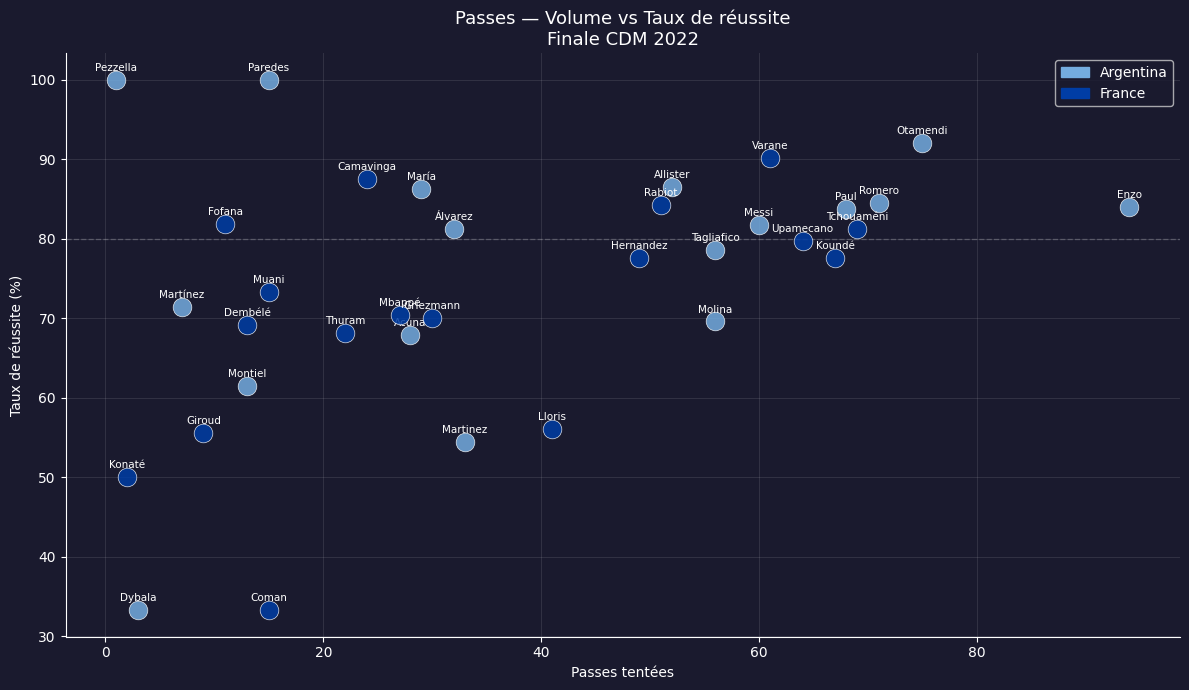

In [20]:

fig, ax = plt.subplots(figsize=(12, 7))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

for _, row in passes_stats.iterrows():
    color = "#003DA5" if row["team"] == "France" else "#74ACDF"
    ax.scatter(row["passes_tentees"], row["taux_passes"],
               s=180, color=color, alpha=0.85,
               edgecolors="white", linewidth=0.5, zorder=3)
    ax.annotate(row["player"].split()[-1],
                (row["passes_tentees"], row["taux_passes"]),
                fontsize=7.5, color="white",
                ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points")

ax.axhline(y=80, color="white", linestyle="--", alpha=0.2, lw=1)
ax.set_xlabel("Passes tentées", color="white")
ax.set_ylabel("Taux de réussite (%)", color="white")
ax.set_title("Passes — Volume vs Taux de réussite\nFinale CDM 2022",
             color="white", fontsize=13)
ax.tick_params(colors="white")
ax.grid(alpha=0.1, color="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

arg_patch = mpatches.Patch(color="#74ACDF", label="Argentina")
fra_patch = mpatches.Patch(color="#003DA5", label="France")
ax.legend(handles=[arg_patch, fra_patch],
          facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig("../reports/figures/passes_scatter.png",
            dpi=150, facecolor='#1a1a2e')
plt.show()


## 15. Volume de jeu : lecture du style de circulation du ballon

Ici, on ne parle pas de distance physique parcourue, mais de **distance parcourue par le ballon** via les passes et les conduites. C’est une manière de voir quels joueurs portent réellement la progression du jeu.

Le classement est très révélateur. Côté français, **Lloris (1.94 km)**, **Upamecano (1.83)** et **Varane (1.68)** apparaissent tout en haut. Cela suggère moins une construction sereine qu’un grand nombre de transmissions défensives, souvent longues, pour échapper à la pression. Côté argentin, **Enzo (1.82)**, **Romero (1.67)**, **Messi (1.57)** et **Otamendi (1.52)** apparaissent dans un cadre beaucoup plus cohérent avec une équipe qui installe son jeu.

le ballon circule beaucoup chez la défense français parce que la France subit plus qu’elle ne choisit, alors que l’Argentine s’appuie sur des profils capables de faire avancer le jeu avec davantage de maîtrise.


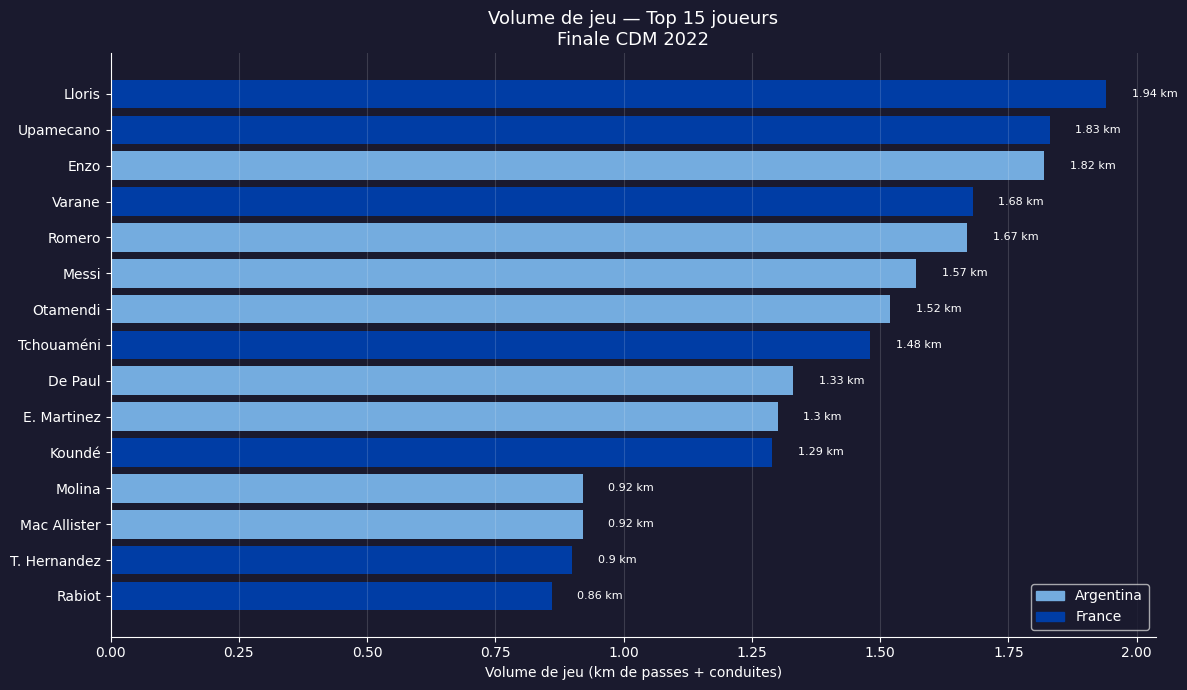

In [21]:
# ============================================================
# 6) BALL PROGRESSION / VOLUME DE JEU
# ============================================================

carries = events[events["type"] == "Carry"].copy()

# Distance des conduites de balle
carries["dist_m"] = carries.apply(
    lambda r: to_meters(distance(r["location"], r["carry_end_location"])),
    axis=1,
)

# Distance des passes
passes["dist_m"] = passes.apply(
    lambda r: to_meters(distance(r["location"], r["pass_end_location"])),
    axis=1,
)

# Fusion = volume total de progression du ballon
movement = pd.concat([carries, passes], ignore_index=True)

dist_joueurs = movement.groupby(["player", "team"])["dist_m"].sum().reset_index()
dist_joueurs["dist_km"] = (dist_joueurs["dist_m"] / 1000).round(2)
dist_joueurs["volume_jeu_km"] = dist_joueurs["dist_km"]

dist_joueurs = dist_joueurs.sort_values("volume_jeu_km", ascending=False)
top15 = dist_joueurs.head(15)

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))
fig.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

colors = ["#003DA5" if t == "France" else "#74ACDF" for t in top15["team"]]

bars = ax.barh(top15["player"], top15["volume_jeu_km"], color=colors)

ax.set_xlabel("Volume de jeu (km de passes + conduites)", color="white")
ax.set_title("Volume de jeu — Top 15 joueurs\nFinale CDM 2022", color="white", fontsize=13)

ax.invert_yaxis()
ax.tick_params(colors="white")
ax.grid(axis="x", alpha=0.15, color="white")

ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, val in zip(bars, top15["volume_jeu_km"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2, f"{val} km", va="center", color="white", fontsize=8)

arg_patch = mpatches.Patch(color="#74ACDF", label="Argentina")
fra_patch = mpatches.Patch(color="#003DA5", label="France")

ax.legend(handles=[arg_patch, fra_patch], facecolor="#1a1a2e", labelcolor="white")

plt.tight_layout()
plt.savefig("../reports/figures/volume_jeu_joueurs.png", dpi=150, facecolor="#1a1a2e")
plt.show()


## 16. Pass maps par joueur : une structure argentine plus lisible

La grille de pass maps permet de voir si la domination technique argentine se traduit par une organisation identifiable joueur par joueur. C’est bien le cas : **Enzo**, **Otamendi**, **Romero**, **De Paul** et **Messi** occupent des rôles complémentaires dans une trame de circulation lisible et plutôt bien distribuée.

Côté français, les cartes font davantage remonter les défenseurs et les joueurs de couloir, avec une circulation moins harmonieuse et souvent plus verticale. Cette lecture s’accorde bien avec le fait que la France a eu plus de mal à imposer un relais créatif stable dans le cœur du jeu.

individuellement : 
**Enzo Fernández** se distingue particulièrement par une activité répartie sur une très grande partie du terrain, ce qui confirme son rôle central dans l’organisation du jeu. **Messi** montre lui aussi une zone de distribution large, en cohérence avec son rôle de lien entre création et finition.

La comparaison avec **Tchouaméni** est intéressante : il participe lui aussi à la circulation, mais autour de lui la structure française semble moins harmonieuse. Plusieurs joueurs français, notamment **Lloris, Upamecano et Varane**, affichent beaucoup de passes longues, souvent orientées vers l’avant. Cela renforce l’idée d’une équipe qui cherche plus souvent à **sauter des lignes** qu’à construire patiemment.

Un autre point clé concerne **Antoine Griezmann**, qui devait normalement être le principal relais créatif côté français, un peu à l’image d’Enzo ou de Messi côté argentin. Or, sa pass map montre une activité relativement limitée et peu influente dans les zones clés. Cela suggère qu’il n’a pas réussi à peser sur le jeu comme attendu, ce qui a fortement impacté la capacité de la France à organiser ses phases offensives.

Le focus suivant zoome sur quatre profils-clés pour préciser cette opposition entre créateurs, relais et finisseurs.


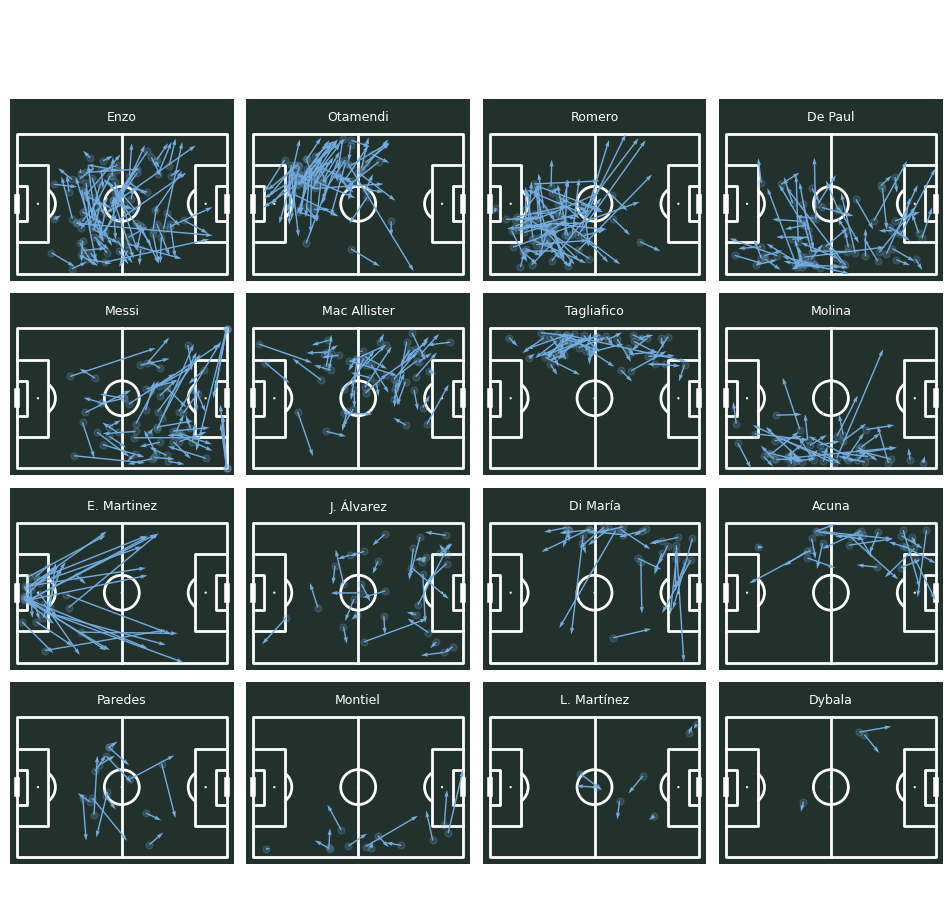

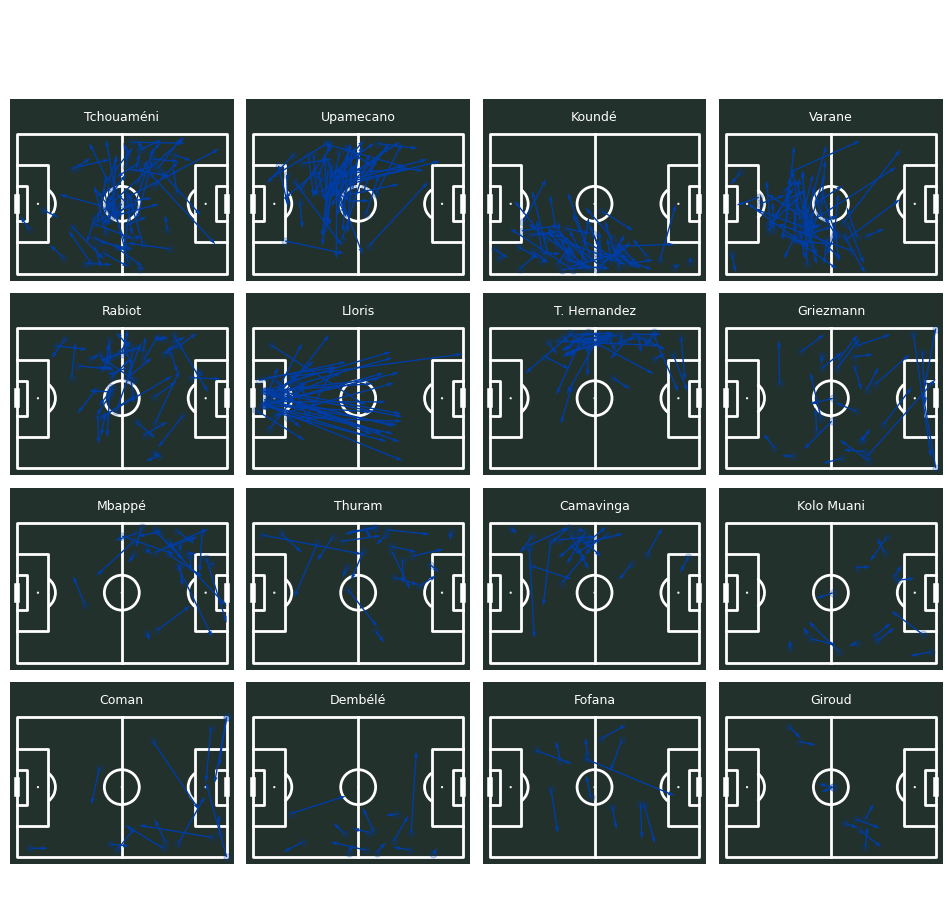

In [22]:
def draw_team_pass_grid(team_name, color):
    mask = (
        (events["type"] == "Pass")
        & (events["team"] == team_name)
        & (events["pass_type"] != "Throw-in")
    )

    df_passes = events.loc[mask, ["x", "y", "end_x", "end_y", "player"]].dropna().copy()
    player_order = (
        df_passes.groupby("player").size().sort_values(ascending=False).index.tolist()
    )
    n = len(player_order)

    pitch = Pitch(line_color="white", pitch_color="#22312b", pad_top=20)
    fig, axs = pitch.grid(
        ncols=4,
        nrows=4,
        grid_height=0.85,
        title_height=0.06,
        axis=False,
        endnote_height=0.04,
        title_space=0.04,
        endnote_space=0.01,
    )

    for player_name, ax in zip(player_order, axs["pitch"].flat[:n]):
        p_df = df_passes[df_passes["player"] == player_name]
        ax.text(60, -10, player_name, ha="center", va="center", fontsize=9, color="white")
        pitch.scatter(p_df["x"], p_df["y"], alpha=0.2, s=25, color=color, ax=ax)
        pitch.arrows(p_df["x"], p_df["y"], p_df["end_x"], p_df["end_y"], color=color, ax=ax, width=1)

    for ax in axs["pitch"].flat[n:]:
        ax.remove()

    axs["title"].text(
        0.5,
        0.5,
        f"{team_name} — Pass Maps (Finale CDM 2022)",
        ha="center",
        va="center",
        fontsize=15,
        color="white",
    )

    safe = team_name.lower().replace(" ", "_")
    plt.savefig(
        f"../reports/figures/passmaps_grid_{safe}.png",
        dpi=150,
        facecolor="#22312b",
        bbox_inches="tight",
    )
    plt.show()


draw_team_pass_grid("Argentina", "#74ACDF")
draw_team_pass_grid("France", "#003DA5")


### Focus — Les pass maps des joueurs-clés

Après la lecture collective des grilles, ce zoom sur quatre profils-clés permet de comparer deux types de relais. **Messi** et **Enzo** montrent comment l’Argentine articule création, orientation et continuité de jeu ; **Mbappé** et **Griezmann** permettent de voir pourquoi la France a eu plus de mal à installer la même densité technique dans le cœur du match.

L’idée n’est donc pas seulement de regarder qui passe le plus, mais **où** et **dans quelle logique** chaque joueur fait circuler le ballon.

- **Argentine** : circulation plus répartie, profils complémentaires, structure plus cohérente  
- **France** : davantage de relances longues depuis l’arrière, organisation moins fluide dans la progression  
- **Griezmann** : rôle créatif en retrait sur ce match, influence limitée dans la construction

> **Insight :**  
> L’absence d’un véritable chef d’orchestre efficace côté français (Griezmann en difficulté) combinée à un jeu plus direct explique en partie pourquoi la France a eu du mal à contrôler le tempo du match.

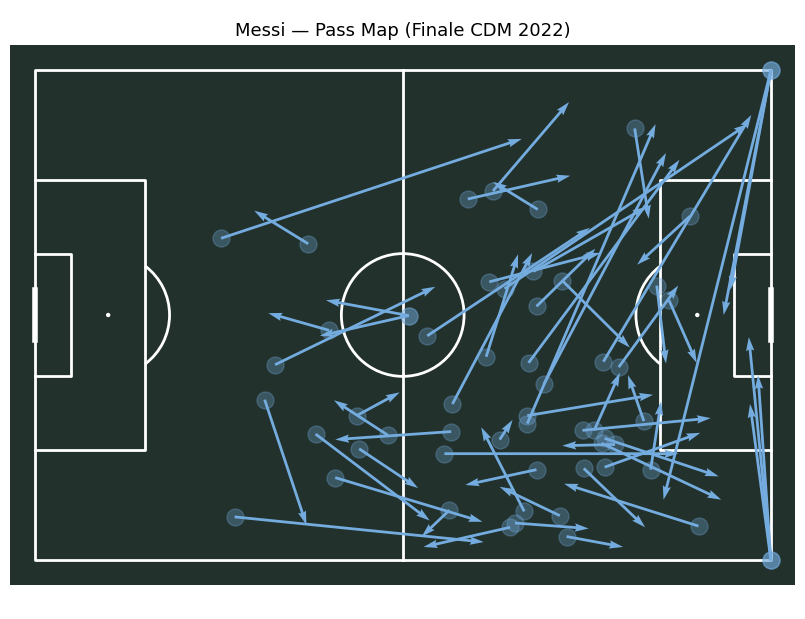

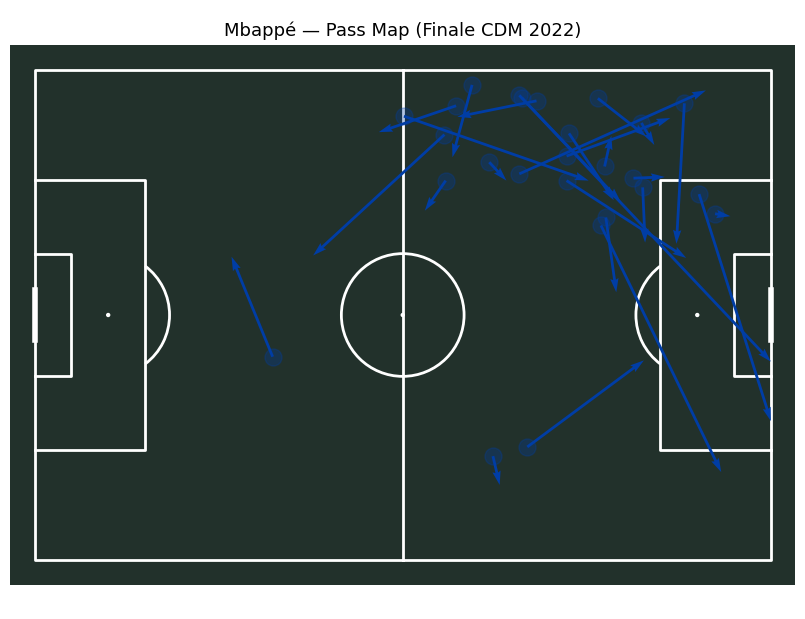

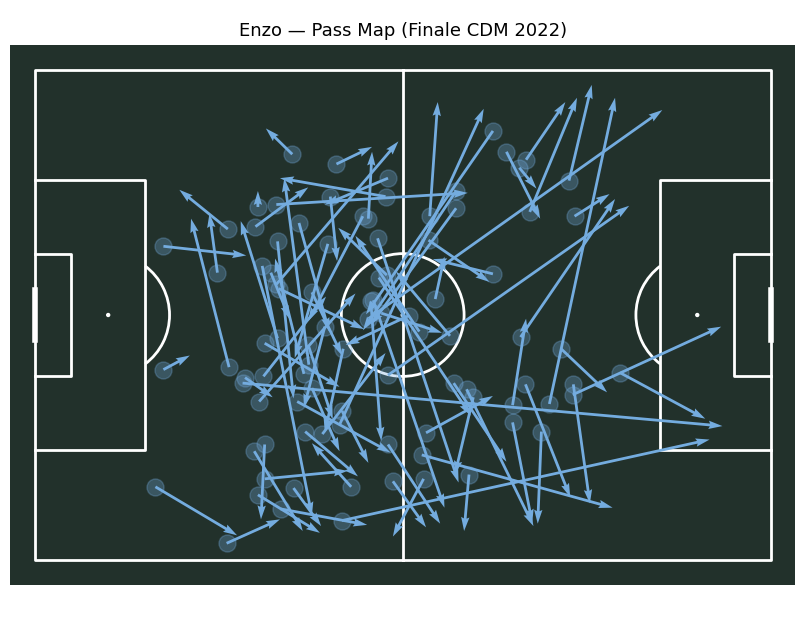

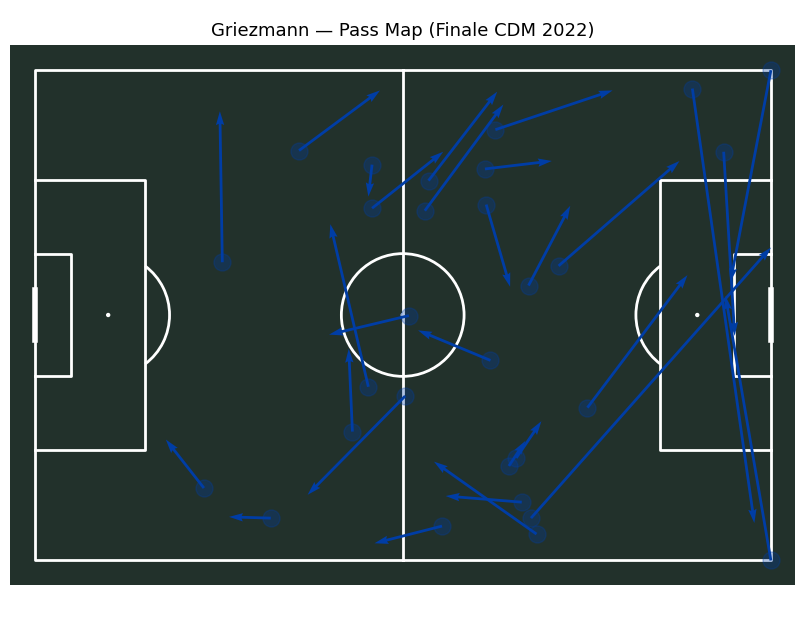

In [23]:
def draw_pass_map_ind(player_name, team_color="#74ACDF"):
    mask = (
        (events["type"] == "Pass")
        & (events["player"] == player_name)
        & (events["pass_type"] != "Throw-in")
    )
    df_pass = events.loc[mask, ["x", "y", "end_x", "end_y"]].dropna().copy()

    pitch = Pitch(line_color="white", pitch_color="#22312b")
    fig, ax = pitch.grid(
        figheight=6,
        grid_height=0.9,
        title_height=0.06,
        axis=False,
        endnote_height=0.04,
        title_space=0,
        endnote_space=0,
    )

    pitch.arrows(
        df_pass["x"],
        df_pass["y"],
        df_pass["end_x"],
        df_pass["end_y"],
        color=team_color,
        ax=ax["pitch"],
        width=2,
    )

    pitch.scatter(df_pass["x"], df_pass["y"], alpha=0.3, s=150, color=team_color, ax=ax["pitch"])

    fig.suptitle(f"{player_name} — Pass Map (Finale CDM 2022)", fontsize=13)
    safe = (
        player_name.lower()
        .replace(" ", "_")
        .replace("é", "e")
        .replace("à", "a")
        .replace("ù", "u")
        .replace("í", "i")
    )
    plt.savefig(
        f"../reports/figures/passmap_{safe}.png",
        dpi=150,
        facecolor="#22312b",
        bbox_inches="tight",
    )
    plt.show()


draw_pass_map_ind("Messi", "#74ACDF")
draw_pass_map_ind("Mbappé", "#003DA5")
draw_pass_map_ind("Enzo", "#74ACDF")
draw_pass_map_ind("Griezmann", "#003DA5")


In [24]:
df_network = events.copy()


## 17. Structure collective & circuits de passes — lecture tactique des deux équipes

Les lignes visibles sur le graphique ne représentent pas toutes les passes entre joueurs.  
Elles montrent uniquement les connexions qui ont été répétées **plus de 5 fois** pendant le match. L’objectif est donc de faire apparaître les **vrais circuits de jeu** et les relations les plus fortes, plutôt que l’ensemble des échanges ponctuels.

### Argentine : un 4-3-3 bien connecté

L’Argentine apparaît dans un **4-3-3** très cohérent, avec une structure compacte et plusieurs relais entre les lignes. La première base de circulation se forme autour de **Romero**, **Otamendi** et surtout **Enzo**, qui joue un rôle central dans la sortie de balle et l’orientation du jeu. C’est un point important : le joueur le plus impliqué dans la circulation argentine est un **milieu de terrain**, ce qui montre que la maîtrise du ballon ne repose pas uniquement sur la défense.

Autour de ce noyau, plusieurs circuits se dégagent clairement :
- **Molina - De Paul - Messi** côté droit,
- **Tagliafico - Mac Allister - Di María** côté gauche.

Le milieu à trois (**Enzo, De Paul, Mac Allister**) relie bien la défense et l’attaque, tandis que **Messi** reste très connecté au jeu au lieu d’être isolé . Cela donne une équipe capable de progresser à la fois dans l’axe et sur les côtés, avec plusieurs solutions courtes.

### France : un 4-2-3-1 plus fragmenté

La France se lit dans un **4-2-3-1**, mais avec une structure beaucoup moins fluide. Le réseau de passes repose surtout sur **Varane**, **Upamecano**, **Koundé** et **Theo Hernández**, ce qui montre que la circulation part beaucoup de la ligne défensive.

Le double pivot **Tchouaméni - Rabiot** existe, mais il ne structure pas autant le jeu que le milieu argentin. Plus haut, **Griezmann**, censé faire le lien entre le milieu et l’attaque dans ce système, apparaît relativement peu connecté. Cela limite la progression dans l’axe et oblige souvent la France à passer par les côtés ou par des transmissions plus directes.

Les circuits les plus visibles sont donc :
- **Theo Hernández - Mbappé** à gauche,
- **Koundé - Dembélé** à droite.

Mais l’ensemble reste plus dispersé, avec moins de connexions fortes entre la base défensive, le milieu et les joueurs offensifs.

### Lecture d’ensemble

Le contraste est net :
- le **4-3-3 argentin** fonctionne comme un bloc bien relié, avec un milieu très actif dans la circulation ;
- le **4-2-3-1 français** apparaît plus cassé, avec une relance souvent portée par la défense et moins de continuité dans le cœur du jeu.

En d’autres termes, l’Argentine construit avec plusieurs relais et plusieurs circuits, alors que la France dépend davantage de sorties latérales et de connexions plus directes vers ses joueurs de couloir, surtout **Mbappé**.

> **Insight :**  
> L’Argentine a mieux fait vivre sa structure collective, avec un 4-3-3 plus dense et plus connecté.  
> La France, dans son 4-2-3-1, a eu plus de mal à relier sa défense, son milieu et son attaque, ce qui explique en partie sa difficulté à contrôler le tempo du match.


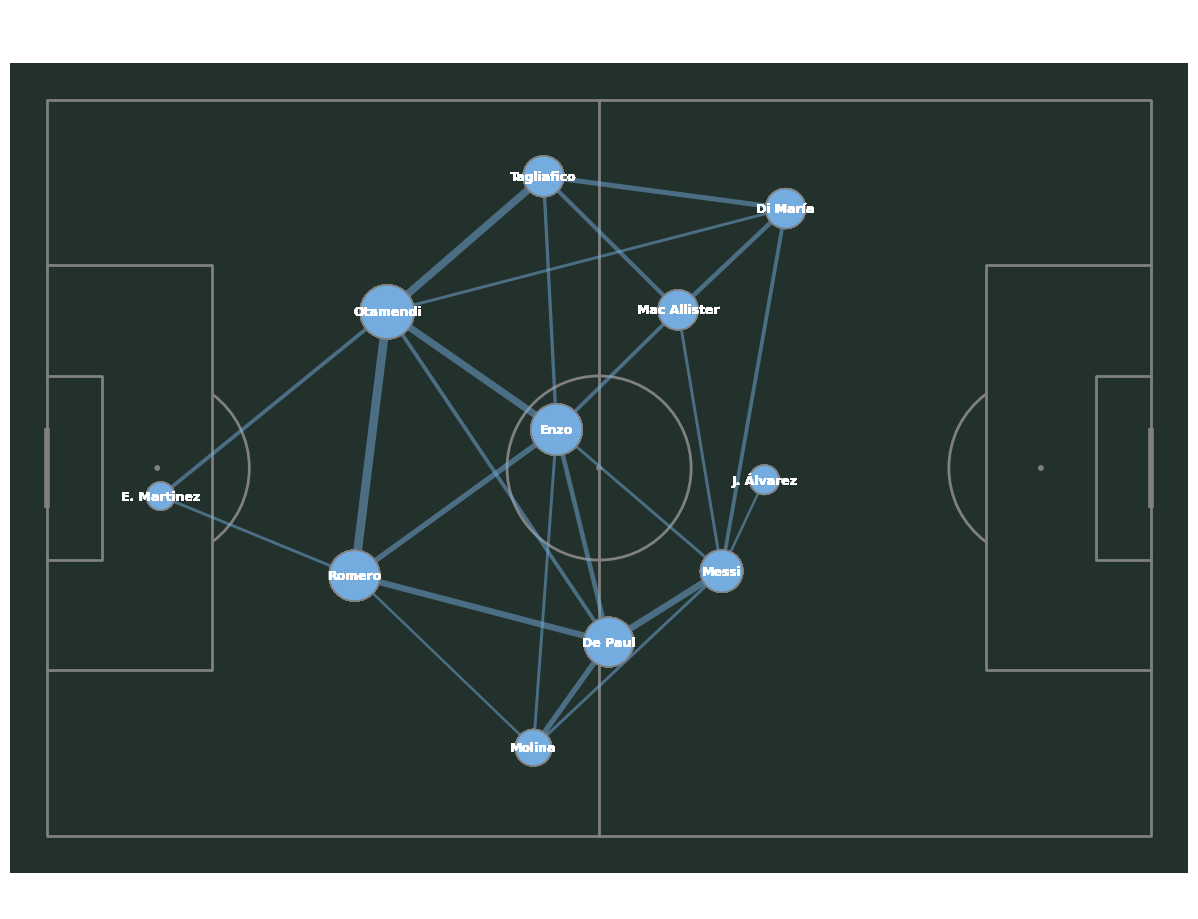

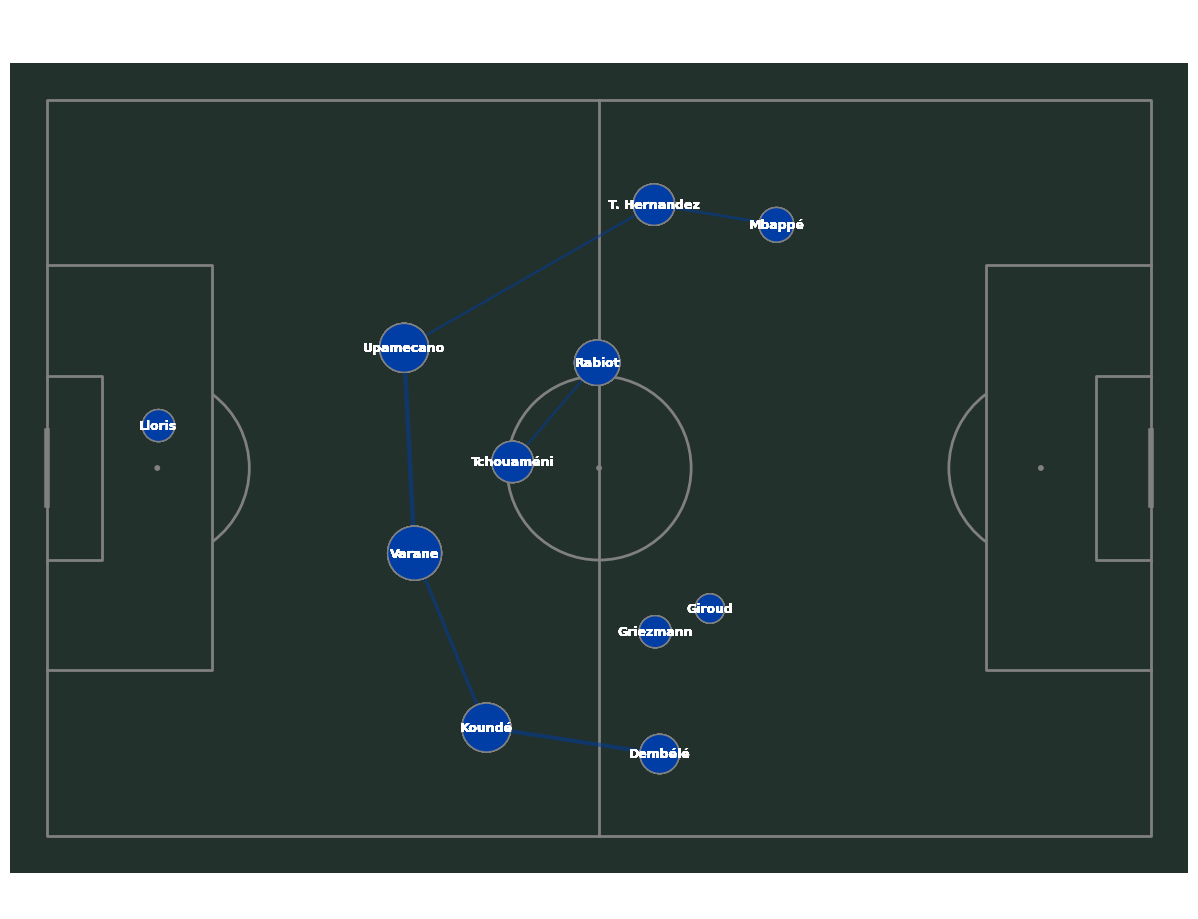

In [25]:
def draw_average_positions(team_name, team_color):
    sub = df_network.loc[
        (df_network["type"] == "Substitution") & (df_network["team"] == team_name)
    ].iloc[0]["index"]

    mask = (
        (df_network["type"] == "Pass")
        & (df_network["team"] == team_name)
        & (df_network["index"] < sub)
        & (df_network["pass_outcome"].isna())
        & (df_network["pass_type"] != "Throw-in")
    )

    df_pass = df_network.loc[
        mask,
        ["x", "y", "end_x", "end_y", "player", "pass_recipient"],
    ].dropna().copy()

    scatter_rows = []
    all_names = pd.Index(df_pass["player"]).union(pd.Index(df_pass["pass_recipient"]))
    for name in all_names:
        passx = df_pass.loc[df_pass["player"] == name, "x"].to_numpy()
        recx = df_pass.loc[df_pass["pass_recipient"] == name, "end_x"].to_numpy()
        passy = df_pass.loc[df_pass["player"] == name, "y"].to_numpy()
        recy = df_pass.loc[df_pass["pass_recipient"] == name, "end_y"].to_numpy()

        xs = np.concatenate([passx, recx]) if len(passx) + len(recx) > 0 else np.array([])
        ys = np.concatenate([passy, recy]) if len(passy) + len(recy) > 0 else np.array([])
        if len(xs) == 0 or len(ys) == 0:
            continue

        scatter_rows.append(
            {
                "player": name,
                "x": xs.mean(),
                "y": ys.mean(),
                "no": int((df_pass["player"] == name).sum()),
            }
        )

    scatter_df = pd.DataFrame(scatter_rows)
    scatter_df["marker_size"] = scatter_df["no"] / scatter_df["no"].max() * 1500

    df_pass["pair_key"] = df_pass.apply(
        lambda row: "|||".join(sorted([str(row["player"]), str(row["pass_recipient"])])),
        axis=1,
    )
    lines_df = df_pass.groupby("pair_key").size().reset_index(name="pass_count")
    lines_df = lines_df[lines_df["pass_count"] > 5]

    pitch = Pitch(line_color="grey", pitch_color="#22312b")
    fig, ax = pitch.grid(
        grid_height=0.9,
        title_height=0.06,
        axis=False,
        endnote_height=0.04,
        title_space=0,
        endnote_space=0,
    )

    for _, row in lines_df.iterrows():
        p1, p2 = row["pair_key"].split("|||")
        p1_row = scatter_df[scatter_df["player"] == p1]
        p2_row = scatter_df[scatter_df["player"] == p2]
        if p1_row.empty or p2_row.empty:
            continue
        pitch.lines(
            p1_row["x"].iloc[0],
            p1_row["y"].iloc[0],
            p2_row["x"].iloc[0],
            p2_row["y"].iloc[0],
            lw=row["pass_count"] * 0.3,
            color=team_color,
            alpha=0.5,
            ax=ax["pitch"],
            zorder=2,
        )

    pitch.scatter(
        scatter_df["x"],
        scatter_df["y"],
        s=scatter_df["marker_size"],
        color=team_color,
        edgecolors="grey",
        linewidth=1,
        alpha=1,
        ax=ax["pitch"],
        zorder=3,
    )

    for _, row in scatter_df.iterrows():
        pitch.annotate(
            row["player"],
            xy=(row["x"], row["y"]),
            c="white",
            va="center",
            ha="center",
            weight="bold",
            size=9,
            ax=ax["pitch"],
            zorder=4,
        )

    ax["title"].text(
        0.5,
        0.5,
        f"Positions moyennes — {team_name} (Finale CDM 2022)",
        ha="center",
        va="center",
        fontsize=16,
        color="white",
    )

    plt.savefig(
        f"../reports/figures/positions_{team_name}.png",
        dpi=150,
        facecolor="#22312b",
    )
    plt.show()


draw_average_positions("Argentina", "#74ACDF")
draw_average_positions("France", "#003DA5")


## Conclusion — Les individualités au service de deux logiques opposées

Le passage du `022` au `033` confirme une idée forte : les individualités ne contredisent pas l’analyse collective, elles la rendent plus lisible. **Messi**, **Enzo**, **De Paul**, **Otamendi** ou **Romero** incarnent une Argentine capable de contrôler le tempo avec plusieurs relais techniques. **Mbappé**, **Kolo Muani**, **Coman** ou **Thuram** incarnent au contraire une France qui retrouve du danger lorsqu’elle réussit à accélérer et à casser le cadre initial du match.

En résumé, le niveau joueur prolonge exactement la lecture d’équipe : l’Argentine domine par l’organisation, la continuité et la distribution des rôles ; la France survit et renverse des séquences grâce à l’explosivité de quelques profils offensifs. C’est cette tension entre structure et irruption qui donne toute sa richesse à la finale.


In [26]:
# ============================================================
# 8) EXPORT FINAL
# ============================================================
recap = dist_joueurs[["player", "team", "volume_jeu_km"]].merge(
    stats_tirs[["player", "tirs", "tirs_cadres", "buts", "xg_total", "precision"]],
    on="player",
    how="left",
).merge(
    dribble_all[["player", "dribbles_tentes", "dribbles_reussis", "taux_reussite"]],
    on="player",
    how="left",
).merge(
    passes_stats[["player", "passes_tentees", "passes_reussies", "taux_passes"]],
    on="player",
    how="left",
).fillna(0)

recap = recap.sort_values("volume_jeu_km", ascending=False)
recap.to_csv("../data/processed/stats_joueurs_finale.csv", index=False)
dist_joueurs.groupby("team")["volume_jeu_km"].sum().reset_index().to_csv(
    "../data/processed/stats_equipes_finale.csv",
    index=False,
)
print("Sauvegardé ✅")

recap.head(20)


Sauvegardé ✅


,player,team,volume_jeu_km,tirs,tirs_cadres,buts,xg_total,precision,dribbles_tentes,dribbles_reussis,taux_reussite,passes_tentees,passes_reussies,taux_passes
0,Lloris,France,1.94,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,41,23,56.1
1,Upamecano,France,1.83,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,64,51,79.7
2,Enzo,Argentina,1.82,2.0,1.0,0.0,0.072,50.0,1.0,1.0,100.0,94,79,84.0
3,Varane,France,1.68,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,61,55,90.2
4,Romero,Argentina,1.67,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,71,60,84.5
5,Messi,Argentina,1.57,5.0,4.0,2.0,1.455,80.0,3.0,0.0,0.0,60,49,81.7
6,Otamendi,Argentina,1.52,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,75,69,92.0
7,Tchouaméni,France,1.48,0.0,0.0,0.0,0.000,0.0,2.0,2.0,100.0,69,56,81.2
8,De Paul,Argentina,1.33,2.0,1.0,0.0,0.103,50.0,4.0,1.0,25.0,68,57,83.8
9,E. Martinez,Argentina,1.30,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,33,18,54.5
